In [71]:
rm(list = ls())
gc()
setwd('/mnt/data00/Minghui/project_NMF/08_Test_NMF_consensus_matrix_V2/')
# library(rliger)
library(dplyr)
library(cowplot)

library(Seurat)
library(ggplot2)
library(parallel)
library(foreach)
library(doParallel)
library(presto)
source('/mnt/data00/Minghui/Function/Markers_kno.R')

source('/mnt/data00/Minghui/Function/seurat_functions.R')

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,13085609,698.9,21150875,1129.6,21150875,1129.6
Vcells,765348734,5839.2,3951150548,30144.9,5074450626,38715.0


Error in library(MSigDB) : there is no package called ‘MSigDB’
Error in library(nichenetr) : there is no package called ‘nichenetr’
Error in library(SeuratDisk) : there is no package called ‘SeuratDisk’
Error in library(SeuratWrappers) : 
  there is no package called ‘SeuratWrappers’
Error in library(genesorteR) : there is no package called ‘genesorteR’


### load files

In [3]:
AllTissue_merge <-readRDS('../02_NMFAllTissue/03_AllTissue_merge.rds')

split_list <- readRDS('/mnt/data00/Minghui/project_NMF/02_NMFAllTissue/01_split_list.rds')

length(split_list)
# 74
split_list

[1] 74

$SRR8513799
An object of class Seurat 
23867 features across 819 samples within 1 assay 
Active assay: RNA (23867 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 11 dimensional reductions calculated: umap_MinDist_0.01_N_Neighbors_15, umap_MinDist_0.05_N_Neighbors_15, umap_MinDist_0.1_N_Neighbors_15, umap_MinDist_0.2_N_Neighbors_15, umap_MinDist_0.3_N_Neighbors_15, umap_MinDist_0.4_N_Neighbors_15, umap_MinDist_0.5_N_Neighbors_15, pca, harmony, umap, tsne

$SRR8513794
An object of class Seurat 
23867 features across 2855 samples within 1 assay 
Active assay: RNA (23867 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 11 dimensional reductions calculated: umap_MinDist_0.01_N_Neighbors_15, umap_MinDist_0.05_N_Neighbors_15, umap_MinDist_0.1_N_Neighbors_15, umap_MinDist_0.2_N_Neighbors_15, umap_MinDist_0.3_N_Neighbors_15, umap_MinDist_0.4_N_Neighbors_15, umap_MinDist_0.5_N_Neighbors_15, pca, harmony, umap, tsne

$SRR8513798
An obje

# Gene selection

In [4]:
#Select HVGs form every sample separatly
hvgs_list <- lapply(split_list, function(seurat_obj) {


    seurat_obj <- FindVariableFeatures(seurat_obj, selection.method = "vst", nfeatures = 3000)
  
    
  VariableFeatures(seurat_obj)
})


names(hvgs_list) <- names(split_list)


Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“at  -2.0062”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“radius  0.00037859”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“all data on boundary of neighborhood. make span bigger”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.0062”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.019457”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  1”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.031008”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“zero-width neighborhood. make span b

In [5]:
head(hvgs_list[[1]],20)

head(hvgs_list[[6]],20)


[1] "PYY"     "GCG"     "AQP8"    "CHGA"    "ZG16"    "TPH1"    "SLC26A3"
 [8] "H4C3"    "OLFM4"   "TFF1"    "PCSK1N"  "CA1"     "GUCA2B"  "UBE2C"  
[15] "CXCL1"   "MT1H"    "FABP1"   "SLC26A2" "BEST4"   "MS4A12"

[1] "PGA4"     "GHRL"     "PGA5"     "TTR"      "PGC"      "APOA1"   
 [7] "MUC6"     "PCSK1N"   "CHIA"     "PGA3"     "LIPF"     "CHGA"    
[13] "DEPP1"    "BPIFB1"   "S100A1"   "C16orf89" "SCG5"     "CRYBA2"  
[19] "NNMT"     "REG1A"

In [6]:
all_hvgs <- unlist(hvgs_list)

hvg_counts <- table(all_hvgs)

head(hvg_counts)

hvg_freq_df <- data.frame(
  gene = names(hvg_counts),
  frequency = as.integer(hvg_counts)
)

hvg_freq_df <- hvg_freq_df[order(-hvg_freq_df$frequency), ]

all_hvgs
    A1BG A1BG.AS1     A1CF      A2M    A2ML1   A4GALT 
       2        1       48       15        2       28 

In [7]:
length(all_hvgs)

head(hvg_freq_df,15)

saveRDS(hvg_freq_df , './01_hvg_freq_sort.rds')

[1] 222000

,gene,frequency
,<chr>,<int>
9208,MT1X,74
14190,STMN1,74
2853,CLU,73
6096,HEPACAM2,73
10526,PCSK1N,73
13837,SOX4,73
15621,TUBA1A,73
3642,DEPP1,72
4500,ERO1B,72


In [8]:
write_csv(x = hvg_freq_df,file = './01_hvg_freq_sort.csv',col_names = TRUE)

### Density Plot of Simulated Gene Frequencies

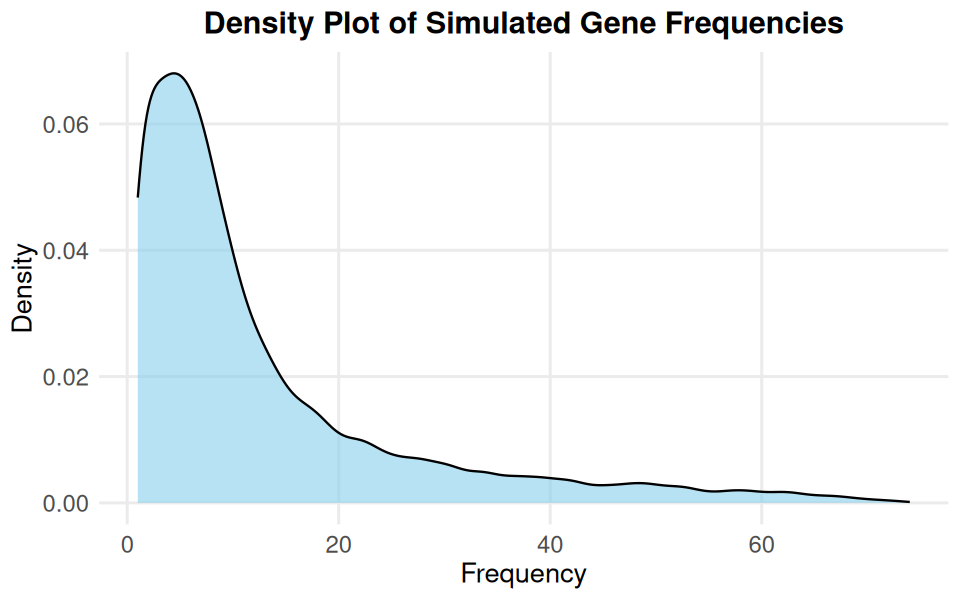

In [10]:
options(repr.plot.width =8, repr.plot.height=5)

ggplot(hvg_freq_df, aes(x = frequency)) +
  geom_density(fill = "skyblue", alpha = 0.6) +
  theme_minimal(base_size = 14) +  
  labs(
    title = "Density Plot of Simulated Gene Frequencies",
    x = "Frequency",
    y = "Density"
  ) +
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),  
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    panel.grid.minor = element_blank() 
  )


In [11]:
dim(hvg_freq_df)

head(hvg_freq_df)

tail(hvg_freq_df)

[1] 17119     2

,gene,frequency
,<chr>,<int>
9208,MT1X,74
14190,STMN1,74
2853,CLU,73
6096,HEPACAM2,73
10526,PCSK1N,73
13837,SOX4,73


,gene,frequency
,<chr>,<int>
17074,ZP1,1
17090,ZSCAN22,1
17091,ZSCAN23,1
17097,ZSCAN32,1
17099,ZSCAN5A.AS1,1
17101,ZSWIM1,1


In [12]:
HVGs <- head(hvg_freq_df$gene,3000)
head(HVGs,30)

[1] "MT1X"     "STMN1"    "CLU"      "HEPACAM2" "PCSK1N"   "SOX4"    
 [7] "TUBA1A"   "DEPP1"    "ERO1B"    "H4C3"     "ID3"      "MT1H"    
[13] "TFF3"     "WFDC2"    "ADH1C"    "AREG"     "CXCL2"    "GADD45B" 
[19] "GDF15"    "MSMB"     "SERPINA1" "TM4SF4"   "BIRC3"    "CHGA"    
[25] "H2AZ1"    "HSPA1A"   "IFI6"     "KCTD12"   "LCN2"     "LDHB"

In [13]:
dir <- "/mnt/fast00/Minghui/matrix_scale_data/"

for (i in names(split_list)) {

     sample_dir <- file.path(dir, i)
  if (!dir.exists(sample_dir)) dir.create(sample_dir, recursive = TRUE)

  # 提取并归一化
  obj <- ScaleData(split_list[[i]], features = HVGs, do.center = FALSE, verbose = FALSE)
  data <- GetAssayData(obj, slot = "scale.data") %>% as.matrix()
  
  # 负数归零
  data[data < 0] <- 0
  
  # 修复方差为 0 的行
  zero_var_rows <- which(apply(data, 1, var) == 0)
  for (j in zero_var_rows) {
    col_index <- sample(ncol(data), 1)
    data[j, col_index] <- 1e-10
  }

  # 保存为 txt 文件到对应子目录
  out_file <- file.path(sample_dir, "scaled_matrix.txt")
  write.table(data, file = out_file, sep = "\t", quote = FALSE, row.names = FALSE,col.names = FALSE)

  message("Scaled matrix saved: ", out_file)
}


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”
Scaled matrix saved: /mnt/fast00/Minghui/matrix_scale_data//SRR8513799/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/matrix_scale_data//SRR8513794/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/matrix_scale_data//SRR8513798/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/matrix_scale_data//GSM3954957/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/matrix_scale_data//Patient21_SIGAA1_GIM/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/matrix_scale_data//Patient02_SIGAD9_NSCJ/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/matrix_scale_data//Patient16_SIGAB1_CIM/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/matrix_scale_data//Patient02_SIGAE9_NG/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/matrix_scale_data//GSM3954950/scaled_matrix.txt

Scaled m

In [14]:
w_dir <- "/home/minghui/output_csv"

w_files <- list.files(w_dir, pattern = "_W.csv$", full.names = TRUE)

w_files  %>% head()

length(w_files)

[1] "/home/minghui/output_csv/GSM3954946_k10_theta03_W.csv"
[2] "/home/minghui/output_csv/GSM3954946_k11_theta03_W.csv"
[3] "/home/minghui/output_csv/GSM3954946_k12_theta03_W.csv"
[4] "/home/minghui/output_csv/GSM3954946_k13_theta03_W.csv"
[5] "/home/minghui/output_csv/GSM3954946_k14_theta03_W.csv"
[6] "/home/minghui/output_csv/GSM3954946_k15_theta03_W.csv"

[1] 1350

In [15]:
w_list <- lapply(w_files, function(f) {
  as.matrix(read.csv(f, header = FALSE))
})


names(w_list) <- basename(w_files)



In [16]:
head(w_list[[2]])

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
0.00000001,0.000000010,0.00000001,0.00000001,0.000000010,0.000000010,0.000000010,0.000000010,0.000000010,0.00000001,0.00000001
0.02949566,0.038365815,0.00000001,0.05734570,0.003095838,0.000000010,0.107198812,0.000000010,0.047228117,0.11923940,0.04057568
0.00000001,0.000000010,0.00000001,0.03504939,0.000000010,0.001437917,0.007720238,0.002687999,0.000000010,0.01061105,0.00000001
0.00000001,0.000000010,0.00000001,0.00000001,0.005113878,0.599669516,0.000000010,0.000000010,0.000000010,0.00000001,0.00000001
0.00000001,0.007280519,0.01686001,0.00000001,0.000000010,0.197542310,0.000000010,0.000000010,0.007203361,0.00000001,0.00000001
0.03718224,0.000000010,0.00000001,0.00000001,0.021936059,0.000000010,0.041005462,0.021384642,0.055011567,0.00000001,0.00000001


In [17]:
coefs_L <- readRDS(file = "/mnt/data00/Minghui/project_NMF/02_NMFAllTissue/03_coefs_L.rds") 


In [18]:
# coefs_L <- readRDS( '../07_Test_NMF_consensus_matrix/03_coefs_L.rds')

length(coefs_L)

[1] 63

In [19]:
lapply(coefs_L, nrow)

$GSM3954946
[1] 11

$GSM3954947
[1] 9

$GSM3954948
[1] 9

$GSM3954949
[1] 10

$GSM3954950
[1] 10

$GSM3954951
[1] 11

$GSM3954952
[1] 10

$GSM3954953
[1] 10

$GSM3954954
[1] 12

$GSM3954955
[1] 9

$GSM3954956
[1] 11

$GSM3954957
[1] 10

$P5846_normal
[1] 4

$P5866_normal_rep2
[1] 14

$P6207_normal
[1] 7

$P6342_normal
[1] 6

$P6592_normal
[1] 8

$P6649_normal
[1] 6

$Patient01_SIGAF2_NSCJ
[1] 13

$Patient01_SIGAG2_NG
[1] 12

$Patient02_SIGAD9_NSCJ
[1] 3

$Patient02_SIGAE9_NG
[1] 11

$Patient03_SIGAB5_BSCJ
[1] 15

$Patient03_SIGAC5_BE
[1] 15

$Patient03_SIGAD5_NG
[1] 10

$Patient07_SIGAB4_BSCJ
[1] 14

$Patient07_SIGAC4_BE
[1] 15

$Patient07_SIGAD4_NG
[1] 12

$Patient07_SIGAE4_ND
[1] 14

$Patient08_SIGAE7_NSCJ
[1] 13

$Patient08_SIGAF7_NG
[1] 10

$Patient08_SIGAG7_ND
[1] 15

$Patient09_SIGAE9_BSCJ
[1] 15

$Patient09_SIGAF9_BE
[1] 13

$Patient09_SIGAG9_NG
[1] 11

$Patient09_SIGAH9_ND
[1] 13

$Patient12_SIGAC3_GM
[1] 8

$Patient12_SIGAE3_ND
[1] 7

$Patient13_SIGAE8_NG
[1] 10

$Patient14_SIGAE8_GIM
[1] 15

$Patient14_SIGAF8_NG
[1] 14

$Patient15_SIGAH11_NG
[1] 10

$Patient16_SIGAA1_GIM
[1] 10

$Patient16_SIGAB1_CIM
[1] 13

$Patient16_SIGAC1_NG
[1] 14

$Patient17_SIGAG7_CIM
[1] 13

$Patient17_SIGAH1_GIM
[1] 14

$Patient17_SIGAH7_NG
[1] 15

$Patient18_SIGAA3_GM
[1] 15

$Patient19_SIGAB3_BE
[1] 10

$Patient20_SIGAC3_GM
[1] 14

$Patient21_SIGAA1_GIM
[1] 9

$Patient21_SIGAB1_CIM
[1] 4

$Patient21_SIGAC1_NG
[1] 11

$Patient22_SIGAE9_GIM
[1] 14

$Patient22_SIGAF9_CIM
[1] 12

$Patient22_SIGAG9_NG
[1] 15

$SRR8513794
[1] 12

$SRR8513795
[1] 15

$SRR8513796
[1] 12

$SRR8513797
[1] 10

$SRR8513798
[1] 11

$SRR8513799
[1] 12

In [20]:
sample_k_list <- c(
  GSM3954946 = 11,
  GSM3954947 = 9,
  GSM3954948 = 9,
  GSM3954949 = 10,
  GSM3954950 = 10,
  GSM3954951 = 11,
  GSM3954952 = 10,
  GSM3954953 = 10,
  GSM3954954 = 12,
  GSM3954955 = 9,
  GSM3954956 = 11,
  GSM3954957 = 10,
  P5846_normal = 4,
  P5866_normal_rep2 = 14,
  P6207_normal = 7,
  P6342_normal = 6,
  P6592_normal = 8,
  P6649_normal = 6,
  Patient01_SIGAF2_NSCJ = 13,
  Patient01_SIGAG2_NG = 12,
  Patient02_SIGAD9_NSCJ = 3,
  Patient02_SIGAE9_NG = 11,
  Patient03_SIGAB5_BSCJ = 15,
  Patient03_SIGAC5_BE = 15,
  Patient03_SIGAD5_NG = 10,
  Patient07_SIGAB4_BSCJ = 14,
  Patient07_SIGAC4_BE = 15,
  Patient07_SIGAD4_NG = 12,
  Patient07_SIGAE4_ND = 14,
  Patient08_SIGAE7_NSCJ = 13,
  Patient08_SIGAF7_NG = 10,
  Patient08_SIGAG7_ND = 15,
  Patient09_SIGAE9_BSCJ = 15,
  Patient09_SIGAF9_BE = 13,
  Patient09_SIGAG9_NG = 11,
  Patient09_SIGAH9_ND = 13,
  Patient12_SIGAC3_GM = 8,
  Patient12_SIGAE3_ND = 7,
  Patient13_SIGAE8_NG = 10,
  Patient14_SIGAE8_GIM = 15,
  Patient14_SIGAF8_NG = 14,
  Patient15_SIGAH11_NG = 10,
  Patient16_SIGAA1_GIM = 10,
  Patient16_SIGAB1_CIM = 13,
  Patient16_SIGAC1_NG = 14,
  Patient17_SIGAG7_CIM = 13,
  Patient17_SIGAH1_GIM = 14,
  Patient17_SIGAH7_NG = 15,
  Patient18_SIGAA3_GM = 15,
  Patient19_SIGAB3_BE = 10,
  Patient20_SIGAC3_GM = 14,
  Patient21_SIGAA1_GIM = 9,
  Patient21_SIGAB1_CIM = 4,
  Patient21_SIGAC1_NG = 11,
  Patient22_SIGAE9_GIM = 14,
  Patient22_SIGAF9_CIM = 12,
  Patient22_SIGAG9_NG = 15,
  SRR8513794 = 12,
  SRR8513795 = 15,
  SRR8513796 = 12,
  SRR8513797 = 10,
  SRR8513798 = 11,
  SRR8513799 = 12
)


In [21]:
length(sample_k_list)

[1] 63

In [22]:
w_dir <- "/home/minghui/output_csv"


target_files <- sapply(names(sample_k_list), function(sample_name) {
  k_value <- sample_k_list[[sample_name]]
  file.path(w_dir, paste0(sample_name, "_k", k_value, "_theta03_W.csv"))
}, USE.NAMES = TRUE)

print(target_files)


                                                        GSM3954946 
           "/home/minghui/output_csv/GSM3954946_k11_theta03_W.csv" 
                                                        GSM3954947 
            "/home/minghui/output_csv/GSM3954947_k9_theta03_W.csv" 
                                                        GSM3954948 
            "/home/minghui/output_csv/GSM3954948_k9_theta03_W.csv" 
                                                        GSM3954949 
           "/home/minghui/output_csv/GSM3954949_k10_theta03_W.csv" 
                                                        GSM3954950 
           "/home/minghui/output_csv/GSM3954950_k10_theta03_W.csv" 
                                                        GSM3954951 
           "/home/minghui/output_csv/GSM3954951_k11_theta03_W.csv" 
                                                        GSM3954952 
           "/home/minghui/output_csv/GSM3954952_k10_theta03_W.csv" 
                                                

In [23]:
class(target_files)

[1] "character"

In [24]:
# 批量读取W矩阵
w_list <- lapply(target_files, function(f) {
  as.matrix(read.csv(f, header = FALSE))
})

# 设置名字为样本名
names(w_list) <- names(target_files)

# 检查
print(names(w_list))


 [1] "GSM3954946"            "GSM3954947"            "GSM3954948"           
 [4] "GSM3954949"            "GSM3954950"            "GSM3954951"           
 [7] "GSM3954952"            "GSM3954953"            "GSM3954954"           
[10] "GSM3954955"            "GSM3954956"            "GSM3954957"           
[13] "P5846_normal"          "P5866_normal_rep2"     "P6207_normal"         
[16] "P6342_normal"          "P6592_normal"          "P6649_normal"         
[19] "Patient01_SIGAF2_NSCJ" "Patient01_SIGAG2_NG"   "Patient02_SIGAD9_NSCJ"
[22] "Patient02_SIGAE9_NG"   "Patient03_SIGAB5_BSCJ" "Patient03_SIGAC5_BE"  
[25] "Patient03_SIGAD5_NG"   "Patient07_SIGAB4_BSCJ" "Patient07_SIGAC4_BE"  
[28] "Patient07_SIGAD4_NG"   "Patient07_SIGAE4_ND"   "Patient08_SIGAE7_NSCJ"
[31] "Patient08_SIGAF7_NG"   "Patient08_SIGAG7_ND"   "Patient09_SIGAE9_BSCJ"
[34] "Patient09_SIGAF9_BE"   "Patient09_SIGAG9_NG"   "Patient09_SIGAH9_ND"  
[37] "Patient12_SIGAC3_GM"   "Patient12_SIGAE3_ND"   "Patient13_SIGAE8_NG"  

In [25]:
names(w_list)

[1] "GSM3954946"            "GSM3954947"            "GSM3954948"           
 [4] "GSM3954949"            "GSM3954950"            "GSM3954951"           
 [7] "GSM3954952"            "GSM3954953"            "GSM3954954"           
[10] "GSM3954955"            "GSM3954956"            "GSM3954957"           
[13] "P5846_normal"          "P5866_normal_rep2"     "P6207_normal"         
[16] "P6342_normal"          "P6592_normal"          "P6649_normal"         
[19] "Patient01_SIGAF2_NSCJ" "Patient01_SIGAG2_NG"   "Patient02_SIGAD9_NSCJ"
[22] "Patient02_SIGAE9_NG"   "Patient03_SIGAB5_BSCJ" "Patient03_SIGAC5_BE"  
[25] "Patient03_SIGAD5_NG"   "Patient07_SIGAB4_BSCJ" "Patient07_SIGAC4_BE"  
[28] "Patient07_SIGAD4_NG"   "Patient07_SIGAE4_ND"   "Patient08_SIGAE7_NSCJ"
[31] "Patient08_SIGAF7_NG"   "Patient08_SIGAG7_ND"   "Patient09_SIGAE9_BSCJ"
[34] "Patient09_SIGAF9_BE"   "Patient09_SIGAG9_NG"   "Patient09_SIGAH9_ND"  
[37] "Patient12_SIGAC3_GM"   "Patient12_SIGAE3_ND"   "Patient13_SIGAE8_NG"  
[40] "Patient14_SIGAE8_GIM"  "Patient14_SIGAF8_NG"   "Patient15_SIGAH11_NG" 
[43] "Patient16_SIGAA1_GIM"  "Patient16_SIGAB1_CIM"  "Patient16_SIGAC1_NG"  
[46] "Patient17_SIGAG7_CIM"  "Patient17_SIGAH1_GIM"  "Patient17_SIGAH7_NG"  
[49] "Patient18_SIGAA3_GM"   "Patient19_SIGAB3_BE"   "Patient20_SIGAC3_GM"  
[52] "Patient21_SIGAA1_GIM"  "Patient21_SIGAB1_CIM"  "Patient21_SIGAC1_NG"  
[55] "Patient22_SIGAE9_GIM"  "Patient22_SIGAF9_CIM"  "Patient22_SIGAG9_NG"  
[58] "SRR8513794"            "SRR8513795"            "SRR8513796"           
[61] "SRR8513797"            "SRR8513798"            "SRR8513799"

In [26]:
gene_names <- HVGs

w_list <- lapply(names(w_list), function(sample_name) {
  mat <- w_list[[sample_name]]
  
  rownames(mat) <- gene_names
  colnames(mat) <- paste0(sample_name, "_Program_", seq_len(ncol(mat)))
  
  return(mat)
})

# 把名字重新加回去
names(w_list) <- names(w_list)

In [27]:

head(w_list[[1]])

,GSM3954946_Program_1,GSM3954946_Program_2,GSM3954946_Program_3,GSM3954946_Program_4,GSM3954946_Program_5,GSM3954946_Program_6,GSM3954946_Program_7,GSM3954946_Program_8,GSM3954946_Program_9,GSM3954946_Program_10,GSM3954946_Program_11
MT1X,0.00000001,0.000000010,0.00000001,0.00000001,0.000000010,0.000000010,0.000000010,0.000000010,0.000000010,0.00000001,0.00000001
STMN1,0.02949566,0.038365815,0.00000001,0.05734570,0.003095838,0.000000010,0.107198812,0.000000010,0.047228117,0.11923940,0.04057568
CLU,0.00000001,0.000000010,0.00000001,0.03504939,0.000000010,0.001437917,0.007720238,0.002687999,0.000000010,0.01061105,0.00000001
HEPACAM2,0.00000001,0.000000010,0.00000001,0.00000001,0.005113878,0.599669516,0.000000010,0.000000010,0.000000010,0.00000001,0.00000001
PCSK1N,0.00000001,0.007280519,0.01686001,0.00000001,0.000000010,0.197542310,0.000000010,0.000000010,0.007203361,0.00000001,0.00000001
SOX4,0.03718224,0.000000010,0.00000001,0.00000001,0.021936059,0.000000010,0.041005462,0.021384642,0.055011567,0.00000001,0.00000001


In [28]:
merge_matrix <- do.call(cbind ,w_list)

dim(merge_matrix)

[1] 3000  710

In [29]:
dim(merge_matrix)

[1] 3000  710

In [30]:
head(merge_matrix , 30)

,GSM3954946_Program_1,GSM3954946_Program_2,GSM3954946_Program_3,GSM3954946_Program_4,GSM3954946_Program_5,GSM3954946_Program_6,GSM3954946_Program_7,GSM3954946_Program_8,GSM3954946_Program_9,GSM3954946_Program_10,⋯,SRR8513799_Program_3,SRR8513799_Program_4,SRR8513799_Program_5,SRR8513799_Program_6,SRR8513799_Program_7,SRR8513799_Program_8,SRR8513799_Program_9,SRR8513799_Program_10,SRR8513799_Program_11,SRR8513799_Program_12
MT1X,1.000000e-08,0.000000010,1.000000e-08,1.000000e-08,0.000000010,0.000000010,0.000000010,1.000000e-08,1.000000e-08,1.000000e-08,⋯,1.000000e-08,0.00000001,0.000000010,0.000000010,0.000000010,0.000000010,0.00000001,0.000000010,0.358556360,0.000000010
STMN1,2.949566e-02,0.038365815,1.000000e-08,5.734570e-02,0.003095838,0.000000010,0.107198812,1.000000e-08,4.722812e-02,1.192394e-01,⋯,1.450786e-01,0.00000001,0.027584976,0.000000010,0.007628025,0.197318241,0.23647650,0.115917176,0.069214456,0.028348332
CLU,1.000000e-08,0.000000010,1.000000e-08,3.504939e-02,0.000000010,0.001437917,0.007720238,2.687999e-03,1.000000e-08,1.061105e-02,⋯,1.000000e-08,0.00000001,0.000000010,0.000000010,0.127977371,0.000000010,0.00000001,0.517135739,0.000000010,0.000000010
HEPACAM2,1.000000e-08,0.000000010,1.000000e-08,1.000000e-08,0.005113878,0.599669516,0.000000010,1.000000e-08,1.000000e-08,1.000000e-08,⋯,1.000000e-08,0.60565770,0.000000010,0.165352896,0.000000010,0.000000010,0.00000001,0.000000010,0.000000010,0.000000010
PCSK1N,1.000000e-08,0.007280519,1.686001e-02,1.000000e-08,0.000000010,0.197542310,0.000000010,1.000000e-08,7.203361e-03,1.000000e-08,⋯,1.000000e-08,0.01143024,0.007651976,0.703136325,0.000000010,0.000000010,0.08972640,0.000000010,0.000000010,0.000000010
SOX4,3.718224e-02,0.000000010,1.000000e-08,1.000000e-08,0.021936059,0.000000010,0.041005462,2.138464e-02,5.501157e-02,1.000000e-08,⋯,1.000000e-08,0.00000001,0.000000010,0.000000010,0.014886698,0.000000010,0.00000001,0.027022632,0.000000010,0.000000010
TUBA1A,3.761431e-03,0.000000010,1.000000e-08,1.000000e-08,0.077671871,0.010257703,0.034035981,5.201193e-02,1.000000e-08,1.000000e-08,⋯,1.000000e-08,0.18996628,0.000000010,0.068031728,0.000000010,0.021779481,0.08696727,0.014105878,0.080255382,0.000000010
DEPP1,1.277036e-02,0.095156632,4.706393e-02,5.109077e-02,0.008206053,0.000000010,0.096473955,1.000000e-08,5.179318e-02,1.000000e-08,⋯,9.992230e-03,0.00000001,0.036054086,0.000000010,0.235013694,0.026983555,0.18048617,0.007286446,0.041103199,0.068146922
ERO1B,1.683911e-02,0.000000010,1.000000e-08,1.588891e-02,0.000000010,0.000000010,0.156720281,1.000000e-08,3.704541e-02,1.000000e-08,⋯,1.579276e-02,0.00000001,0.000000010,0.000000010,0.048691005,0.033135239,0.05981069,0.000000010,0.000000010,0.088360339
H4C3,2.754458e-07,0.021130264,1.000000e-08,6.512191e-03,0.068396889,0.053242475,0.070310876,1.000000e-08,7.100216e-02,1.000000e-08,⋯,8.945440e-02,0.00000001,0.000000010,0.000000010,0.000000010,0.000000010,0.01031286,0.065199122,0.000000010,0.000000010


In [31]:
# mat <- matrix(rnorm(100 * 20), nrow = 100)

mat_unit <- apply(merge_matrix, 2, function(x) x / sqrt(sum(x^2))) #L2 normalize the columns

In [32]:
saveRDS(mat_unit , './02_L2morm_matrix.rds')

saveRDS(merge_matrix, './02_merge_matrix.rds')

In [33]:
mat_unit <- readRDS('./02_L2morm_matrix.rds')

merge_matrix <- readRDS('./02_merge_matrix.rds')

,GSM3954946_Program_1,GSM3954946_Program_2,GSM3954946_Program_3,GSM3954946_Program_4,GSM3954946_Program_5,GSM3954946_Program_6,GSM3954946_Program_7,GSM3954946_Program_8,GSM3954946_Program_9,GSM3954946_Program_10,⋯,SRR8513799_Program_3,SRR8513799_Program_4,SRR8513799_Program_5,SRR8513799_Program_6,SRR8513799_Program_7,SRR8513799_Program_8,SRR8513799_Program_9,SRR8513799_Program_10,SRR8513799_Program_11,SRR8513799_Program_12
MT1X,2.591845e-09,2.665444e-09,1.510994e-09,2.792727e-09,1.881090e-09,1.842431e-09,1.688625e-09,3.596177e-09,1.852584e-09,1.736967e-09,⋯,1.585890e-09,1.386783e-09,1.797248e-09,1.411626e-09,1.559672e-09,1.439456e-09,1.132896e-09,1.517021e-09,5.810316e-02,1.322534e-09
STMN1,7.644819e-03,1.022619e-02,1.510994e-09,1.601509e-02,5.823550e-04,1.842431e-09,1.810186e-02,3.596177e-09,8.749403e-03,2.071149e-02,⋯,2.300786e-02,1.386783e-09,4.957705e-03,1.411626e-09,1.189722e-03,2.840309e-02,2.679033e-02,1.758488e-02,1.121603e-02,3.749162e-03
CLU,2.591845e-09,2.665444e-09,1.510994e-09,9.788337e-03,1.881090e-09,2.649264e-04,1.303659e-03,9.666518e-04,1.852584e-09,1.843105e-03,⋯,1.585890e-09,1.386783e-09,1.797248e-09,1.411626e-09,1.996027e-02,1.439456e-09,1.132896e-09,7.845058e-02,1.620475e-09,1.322534e-09
HEPACAM2,2.591845e-09,2.665444e-09,1.510994e-09,2.792727e-09,9.619666e-04,1.104850e-01,1.688625e-09,3.596177e-09,1.852584e-09,1.736967e-09,⋯,1.585890e-09,8.399158e-02,1.797248e-09,2.334165e-02,1.559672e-09,1.439456e-09,1.132896e-09,1.517021e-09,1.620475e-09,1.322534e-09
PCSK1N,2.591845e-09,1.940581e-03,2.547537e-03,2.792727e-09,1.881090e-09,3.639581e-02,1.688625e-09,3.596177e-09,1.334483e-03,1.736967e-09,⋯,1.585890e-09,1.585127e-03,1.375250e-03,9.925657e-02,1.559672e-09,1.439456e-09,1.016507e-02,1.517021e-09,1.620475e-09,1.322534e-09
SOX4,9.637061e-03,2.665444e-09,1.510994e-09,2.792727e-09,4.126371e-03,1.842431e-09,6.924286e-03,7.690295e-03,1.019135e-02,1.736967e-09,⋯,1.585890e-09,1.386783e-09,1.797248e-09,1.411626e-09,2.321836e-03,1.439456e-09,1.132896e-09,4.099390e-03,1.620475e-09,1.322534e-09


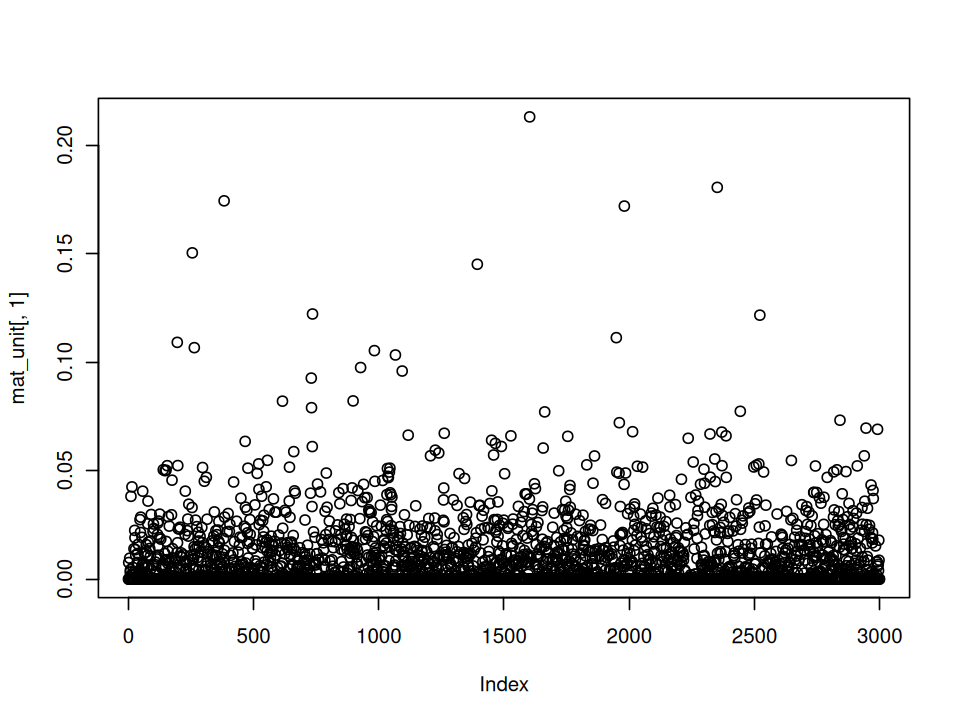

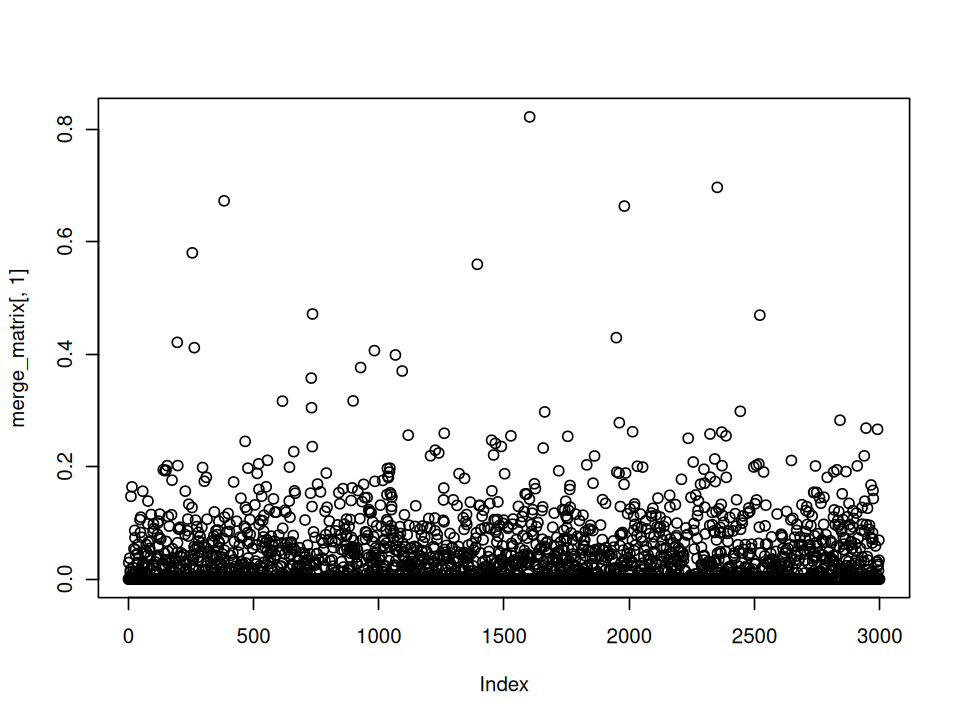

In [34]:
options(repr.plot.width =8, repr.plot.height=6)

head(mat_unit)

plot(mat_unit[,1])

plot(merge_matrix[,1])


In [35]:
# use the kmedoid instead kmeans
pam_data <- pam(t(mat_unit),20 )

In [36]:
library(vegan)

otu_dist=vegdist(t(mat_unit), method="bray", diag=TRUE, upper=TRUE, p=2)

head(otu_dist)

library(fpc)
library(cluster)
pambest=pamk(otu_dist)
k=pambest$nc

Loading required package: permute


Attaching package: ‘permute’


The following object is masked from ‘package:igraph’:

    permute



Attaching package: ‘vegan’


The following object is masked from ‘package:caret’:

    tolerance


The following object is masked from ‘package:igraph’:

    diversity


Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



[1] 0.7192061 0.7114867 0.7637384 0.7311316 0.8161202 0.5598720

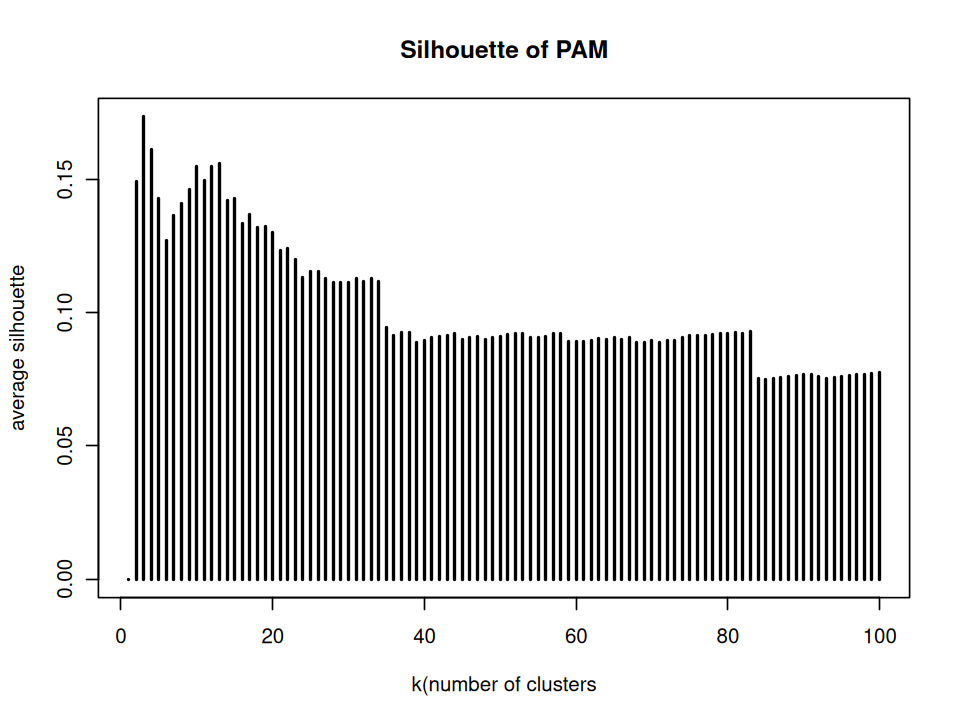

In [37]:
asw <- numeric(100)
for (i in 2:100) {
  asw[i]=pam(otu_dist, i)$silinfo$avg.width
}
k.best=which.max(asw)
plot(1:length(asw), asw, type="h", main="Silhouette of PAM", lwd=2,
     xlab="k(number of clusters", ylab="average silhouette")

In [48]:
max(asw[30:40])

which(asw== max(asw[30:40]))

[1] 0.1128548

[1] 31

In [41]:
names(pam_data)

[1] "medoids"    "id.med"     "clustering" "objective"  "isolation" 
 [6] "clusinfo"   "silinfo"    "diss"       "call"       "data"

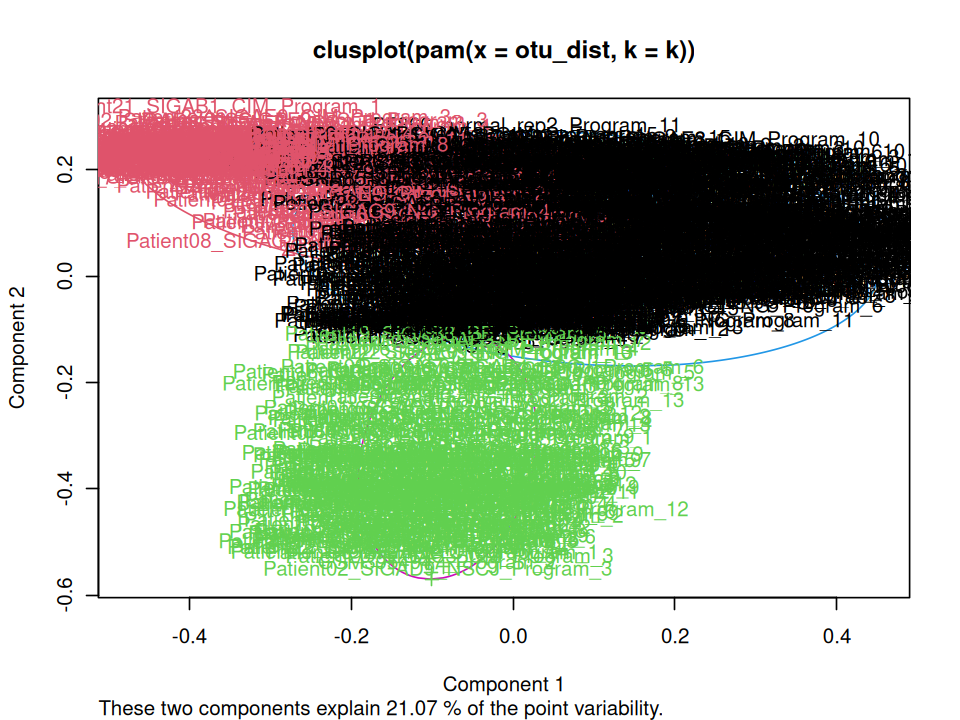

In [39]:
options(repr.plot.width =8, repr.plot.height=6)
otu_pam=pam(otu_dist, k)

clusplot(otu_pam, color=TRUE, labels=3, lines=0, cex=1,  col.p=otu_pam$clustering)


In [287]:
head(mat_unit)

,GSM3954946_Program_1,GSM3954946_Program_2,GSM3954946_Program_3,GSM3954946_Program_4,GSM3954946_Program_5,GSM3954946_Program_6,GSM3954946_Program_7,GSM3954946_Program_8,GSM3954946_Program_9,GSM3954946_Program_10,⋯,SRR8513799_Program_3,SRR8513799_Program_4,SRR8513799_Program_5,SRR8513799_Program_6,SRR8513799_Program_7,SRR8513799_Program_8,SRR8513799_Program_9,SRR8513799_Program_10,SRR8513799_Program_11,SRR8513799_Program_12
MT1X,2.591845e-09,2.665444e-09,1.510994e-09,2.792727e-09,1.881090e-09,1.842431e-09,1.688625e-09,3.596177e-09,1.852584e-09,1.736967e-09,⋯,1.585890e-09,1.386783e-09,1.797248e-09,1.411626e-09,1.559672e-09,1.439456e-09,1.132896e-09,1.517021e-09,5.810316e-02,1.322534e-09
STMN1,7.644819e-03,1.022619e-02,1.510994e-09,1.601509e-02,5.823550e-04,1.842431e-09,1.810186e-02,3.596177e-09,8.749403e-03,2.071149e-02,⋯,2.300786e-02,1.386783e-09,4.957705e-03,1.411626e-09,1.189722e-03,2.840309e-02,2.679033e-02,1.758488e-02,1.121603e-02,3.749162e-03
CLU,2.591845e-09,2.665444e-09,1.510994e-09,9.788337e-03,1.881090e-09,2.649264e-04,1.303659e-03,9.666518e-04,1.852584e-09,1.843105e-03,⋯,1.585890e-09,1.386783e-09,1.797248e-09,1.411626e-09,1.996027e-02,1.439456e-09,1.132896e-09,7.845058e-02,1.620475e-09,1.322534e-09
HEPACAM2,2.591845e-09,2.665444e-09,1.510994e-09,2.792727e-09,9.619666e-04,1.104850e-01,1.688625e-09,3.596177e-09,1.852584e-09,1.736967e-09,⋯,1.585890e-09,8.399158e-02,1.797248e-09,2.334165e-02,1.559672e-09,1.439456e-09,1.132896e-09,1.517021e-09,1.620475e-09,1.322534e-09
PCSK1N,2.591845e-09,1.940581e-03,2.547537e-03,2.792727e-09,1.881090e-09,3.639581e-02,1.688625e-09,3.596177e-09,1.334483e-03,1.736967e-09,⋯,1.585890e-09,1.585127e-03,1.375250e-03,9.925657e-02,1.559672e-09,1.439456e-09,1.016507e-02,1.517021e-09,1.620475e-09,1.322534e-09
SOX4,9.637061e-03,2.665444e-09,1.510994e-09,2.792727e-09,4.126371e-03,1.842431e-09,6.924286e-03,7.690295e-03,1.019135e-02,1.736967e-09,⋯,1.585890e-09,1.386783e-09,1.797248e-09,1.411626e-09,2.321836e-03,1.439456e-09,1.132896e-09,4.099390e-03,1.620475e-09,1.322534e-09


In [49]:
k = 31

pam_data <- pam(t(mat_unit),k )

In [50]:
medoid_names <- pam_data$medoids

# Extract these columns (corresponding to medoid) from the original matrix
medoid_vectors <- mat_unit[, rownames( pam_data$medoids)]

In [51]:
head(medoid_vectors)

,GSM3954950_Program_10,SRR8513798_Program_4,Patient22_SIGAG9_NG_Program_6,Patient16_SIGAA1_GIM_Program_1,GSM3954950_Program_3,GSM3954950_Program_8,Patient03_SIGAC5_BE_Program_12,GSM3954950_Program_4,GSM3954955_Program_8,Patient02_SIGAD9_NSCJ_Program_2,⋯,Patient16_SIGAA1_GIM_Program_8,Patient16_SIGAB1_CIM_Program_12,Patient12_SIGAC3_GM_Program_6,SRR8513797_Program_6,Patient02_SIGAE9_NG_Program_2,Patient14_SIGAE8_GIM_Program_13,Patient22_SIGAG9_NG_Program_3,Patient14_SIGAE8_GIM_Program_6,Patient22_SIGAG9_NG_Program_13,SRR8513797_Program_9
MT1X,1.746553e-09,1.431572e-09,1.195476e-09,1.233519e-09,1.025300e-03,1.530731e-09,1.048068e-09,2.414184e-09,9.774643e-10,9.416661e-05,⋯,2.971291e-02,8.381327e-03,3.649697e-04,1.216080e-09,1.367471e-09,1.550497e-09,1.361838e-09,1.301801e-03,2.024175e-09,1.444019e-09
STMN1,1.204377e-05,3.871505e-03,4.710644e-03,8.240336e-03,6.468011e-03,1.530731e-09,3.470324e-02,2.414184e-09,9.702821e-03,1.119043e-02,⋯,2.021143e-02,5.377691e-03,3.339960e-03,2.364094e-02,3.628155e-03,1.161376e-02,2.047568e-03,1.459218e-02,1.464523e-02,6.066881e-03
CLU,1.746553e-09,3.045745e-02,1.195476e-09,1.233519e-09,3.766457e-04,1.530731e-09,8.308436e-03,2.414184e-09,1.342058e-03,1.291698e-03,⋯,3.212038e-03,1.482176e-09,9.923321e-10,1.216080e-09,5.147577e-02,1.550497e-09,8.210946e-03,1.484292e-09,2.024175e-09,1.179326e-01
HEPACAM2,2.007637e-03,1.431572e-09,3.560873e-03,1.233519e-09,1.675195e-02,5.270186e-02,2.574507e-08,1.604192e-02,5.753389e-02,2.006914e-02,⋯,5.833538e-03,8.134910e-03,1.149452e-02,1.216080e-09,2.034630e-02,1.560967e-02,8.179370e-02,7.154578e-03,3.423511e-03,2.703397e-02
PCSK1N,1.768999e-03,1.431572e-09,1.195476e-09,1.233519e-09,1.736337e-09,8.112904e-03,1.048068e-09,2.414184e-09,2.069423e-02,4.519678e-03,⋯,1.155401e-09,1.482176e-09,9.923321e-10,1.216080e-09,1.367471e-09,1.550497e-09,1.971086e-02,1.484292e-09,2.024175e-09,1.444019e-09
SOX4,2.513465e-03,1.431572e-09,1.195476e-09,1.233519e-09,7.222447e-03,1.530731e-09,1.048068e-09,2.414184e-09,9.774643e-10,7.150628e-03,⋯,2.787072e-02,1.556766e-02,9.923321e-10,1.216080e-09,1.849754e-02,3.092013e-02,3.450926e-03,1.683086e-02,2.024175e-09,1.444019e-09


In [52]:
class(medoid_vectors)

dim(medoid_vectors)

head(medoid_vectors)

[1] "matrix" "array"

[1] 3000   31

,GSM3954950_Program_10,SRR8513798_Program_4,Patient22_SIGAG9_NG_Program_6,Patient16_SIGAA1_GIM_Program_1,GSM3954950_Program_3,GSM3954950_Program_8,Patient03_SIGAC5_BE_Program_12,GSM3954950_Program_4,GSM3954955_Program_8,Patient02_SIGAD9_NSCJ_Program_2,⋯,Patient16_SIGAA1_GIM_Program_8,Patient16_SIGAB1_CIM_Program_12,Patient12_SIGAC3_GM_Program_6,SRR8513797_Program_6,Patient02_SIGAE9_NG_Program_2,Patient14_SIGAE8_GIM_Program_13,Patient22_SIGAG9_NG_Program_3,Patient14_SIGAE8_GIM_Program_6,Patient22_SIGAG9_NG_Program_13,SRR8513797_Program_9
MT1X,1.746553e-09,1.431572e-09,1.195476e-09,1.233519e-09,1.025300e-03,1.530731e-09,1.048068e-09,2.414184e-09,9.774643e-10,9.416661e-05,⋯,2.971291e-02,8.381327e-03,3.649697e-04,1.216080e-09,1.367471e-09,1.550497e-09,1.361838e-09,1.301801e-03,2.024175e-09,1.444019e-09
STMN1,1.204377e-05,3.871505e-03,4.710644e-03,8.240336e-03,6.468011e-03,1.530731e-09,3.470324e-02,2.414184e-09,9.702821e-03,1.119043e-02,⋯,2.021143e-02,5.377691e-03,3.339960e-03,2.364094e-02,3.628155e-03,1.161376e-02,2.047568e-03,1.459218e-02,1.464523e-02,6.066881e-03
CLU,1.746553e-09,3.045745e-02,1.195476e-09,1.233519e-09,3.766457e-04,1.530731e-09,8.308436e-03,2.414184e-09,1.342058e-03,1.291698e-03,⋯,3.212038e-03,1.482176e-09,9.923321e-10,1.216080e-09,5.147577e-02,1.550497e-09,8.210946e-03,1.484292e-09,2.024175e-09,1.179326e-01
HEPACAM2,2.007637e-03,1.431572e-09,3.560873e-03,1.233519e-09,1.675195e-02,5.270186e-02,2.574507e-08,1.604192e-02,5.753389e-02,2.006914e-02,⋯,5.833538e-03,8.134910e-03,1.149452e-02,1.216080e-09,2.034630e-02,1.560967e-02,8.179370e-02,7.154578e-03,3.423511e-03,2.703397e-02
PCSK1N,1.768999e-03,1.431572e-09,1.195476e-09,1.233519e-09,1.736337e-09,8.112904e-03,1.048068e-09,2.414184e-09,2.069423e-02,4.519678e-03,⋯,1.155401e-09,1.482176e-09,9.923321e-10,1.216080e-09,1.367471e-09,1.550497e-09,1.971086e-02,1.484292e-09,2.024175e-09,1.444019e-09
SOX4,2.513465e-03,1.431572e-09,1.195476e-09,1.233519e-09,7.222447e-03,1.530731e-09,1.048068e-09,2.414184e-09,9.774643e-10,7.150628e-03,⋯,2.787072e-02,1.556766e-02,9.923321e-10,1.216080e-09,1.849754e-02,3.092013e-02,3.450926e-03,1.683086e-02,2.024175e-09,1.444019e-09


In [244]:
# cluster_components <- function(filtered_data, k = NULL) {
#  set.seed(123)  
#   kmeans_result <- kmeans(t(mat_unit), centers = k, nstart = 25)
  
#   return(list(
#     clusters = kmeans_result$cluster,
#     centers = kmeans_result$centers,
#     totss = kmeans_result$totss,
#     withinss = kmeans_result$withinss,
#     tot.withinss = kmeans_result$tot.withinss,
#     betweenss = kmeans_result$betweenss,
#     size = kmeans_result$size,
#     k = k
#   ))
# }

# clustering_result <- cluster_components(merge_matrix, k = k)


In [53]:
# 批量读取W矩阵
w_list <- lapply(target_files, function(f) {
  as.matrix(read.csv(f, header = FALSE))
})

# 设置名字为样本名
names(w_list) <- names(target_files)

# 检查
print(names(w_list))


 [1] "GSM3954946"            "GSM3954947"            "GSM3954948"           
 [4] "GSM3954949"            "GSM3954950"            "GSM3954951"           
 [7] "GSM3954952"            "GSM3954953"            "GSM3954954"           
[10] "GSM3954955"            "GSM3954956"            "GSM3954957"           
[13] "P5846_normal"          "P5866_normal_rep2"     "P6207_normal"         
[16] "P6342_normal"          "P6592_normal"          "P6649_normal"         
[19] "Patient01_SIGAF2_NSCJ" "Patient01_SIGAG2_NG"   "Patient02_SIGAD9_NSCJ"
[22] "Patient02_SIGAE9_NG"   "Patient03_SIGAB5_BSCJ" "Patient03_SIGAC5_BE"  
[25] "Patient03_SIGAD5_NG"   "Patient07_SIGAB4_BSCJ" "Patient07_SIGAC4_BE"  
[28] "Patient07_SIGAD4_NG"   "Patient07_SIGAE4_ND"   "Patient08_SIGAE7_NSCJ"
[31] "Patient08_SIGAF7_NG"   "Patient08_SIGAG7_ND"   "Patient09_SIGAE9_BSCJ"
[34] "Patient09_SIGAF9_BE"   "Patient09_SIGAG9_NG"   "Patient09_SIGAH9_ND"  
[37] "Patient12_SIGAC3_GM"   "Patient12_SIGAE3_ND"   "Patient13_SIGAE8_NG"  

In [54]:
AllTissue_merge <- subset(AllTissue_merge,sample_name %in% names(w_list))
AllTissue_merge  <- ScaleData(object = AllTissue_merge,do.center = F,features =rownames(merge_matrix) )  
norm_expression <- AllTissue_merge@assays$RNA@scale.data


Scaling data matrix



In [55]:

compute_usage_matrix_parallel <- function(norm_expression, norm_components, n_cores = NULL) {
  
  library(nnls)
  library(doParallel)
  library(foreach)
  

  n_cells <- ncol(norm_expression)
  n_components <- ncol(norm_components)
  usage_matrix <- matrix(0, nrow = n_cells, ncol = n_components)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  cl <- makeCluster(n_cores)
  registerDoParallel(cl)
  
  clusterExport(cl, c("norm_components"), envir = environment())
  
  # NNLS
  usage_list <- foreach(i = 1:n_cells, .packages = "nnls") %dopar% {
    fit <- nnls::nnls(norm_components, norm_expression[, i])
    fit$x
  }
  
  stopCluster(cl)
  
  usage_matrix <- do.call(rbind, usage_list)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  return(usage_matrix)
}

In [56]:
# Parallel 
chunk_size <- 1000  # cell number in every chunks
chunks <- split(1:ncol(norm_expression), ceiling(seq_along(1:ncol(norm_expression))/chunk_size))

results <- lapply(chunks, function(idx) {
  compute_usage_matrix_parallel(norm_expression[, idx],n_cores = 25, medoid_vectors)
})

usage_matrix <- do.call(rbind, results)

In [57]:
head(usage_matrix)

,GSM3954950_Program_10,SRR8513798_Program_4,Patient22_SIGAG9_NG_Program_6,Patient16_SIGAA1_GIM_Program_1,GSM3954950_Program_3,GSM3954950_Program_8,Patient03_SIGAC5_BE_Program_12,GSM3954950_Program_4,GSM3954955_Program_8,Patient02_SIGAD9_NSCJ_Program_2,⋯,Patient16_SIGAA1_GIM_Program_8,Patient16_SIGAB1_CIM_Program_12,Patient12_SIGAC3_GM_Program_6,SRR8513797_Program_6,Patient02_SIGAE9_NG_Program_2,Patient14_SIGAE8_GIM_Program_13,Patient22_SIGAG9_NG_Program_3,Patient14_SIGAE8_GIM_Program_6,Patient22_SIGAG9_NG_Program_13,SRR8513797_Program_9
SRR8513799-CTCACACGTCACCCAG-1,0,2.555677,0,0.05014949,0,0,4.468476,0.9126822,5.993470,0,⋯,0,0.09106289,0.000000,6.314067,0.6801809,0.0000000,0.000000,0,0.4260140,9.421784
SRR8513799-TACAGTGGTCATCCCT-1,0,2.963395,0,0.00000000,0,0,8.733368,0.0000000,0.000000,0,⋯,0,0.00000000,0.000000,12.919171,0.0000000,0.0000000,0.000000,0,1.1931794,14.868384
SRR8513799-GCACATACACTGTCGG-1,0,0.000000,0,0.00000000,0,0,11.579820,0.7031631,0.000000,0,⋯,0,0.00000000,0.000000,11.958905,0.0000000,0.2856298,0.000000,0,1.8718430,17.778418
SRR8513799-CTGAAACTCTGGCGAC-1,0,23.261084,0,0.00000000,0,0,9.094130,0.0000000,1.928289,0,⋯,0,0.00000000,1.180163,8.328500,0.0000000,0.0000000,0.000000,0,0.6887540,5.469640
SRR8513799-AGTAGTCAGTGAAGAG-1,0,0.000000,0,0.00000000,0,0,0.000000,0.1443978,3.491550,0,⋯,0,0.00000000,0.000000,7.104836,1.7090869,0.0000000,0.000000,0,0.3756563,1.552628
SRR8513799-ATCCGAACAACGATGG-1,0,0.000000,0,0.28076628,0,0,0.000000,0.0000000,0.000000,0,⋯,0,0.00000000,0.000000,0.000000,0.0000000,0.0000000,0.577004,0,2.2659100,4.627806


In [58]:
colnames(usage_matrix)

[1] "GSM3954950_Program_10"           "SRR8513798_Program_4"           
 [3] "Patient22_SIGAG9_NG_Program_6"   "Patient16_SIGAA1_GIM_Program_1" 
 [5] "GSM3954950_Program_3"            "GSM3954950_Program_8"           
 [7] "Patient03_SIGAC5_BE_Program_12"  "GSM3954950_Program_4"           
 [9] "GSM3954955_Program_8"            "Patient02_SIGAD9_NSCJ_Program_2"
[11] "Patient20_SIGAC3_GM_Program_5"   "GSM3954950_Program_6"           
[13] "Patient21_SIGAB1_CIM_Program_2"  "Patient07_SIGAD4_NG_Program_8"  
[15] "Patient07_SIGAD4_NG_Program_7"   "Patient22_SIGAG9_NG_Program_14" 
[17] "Patient16_SIGAA1_GIM_Program_7"  "Patient03_SIGAC5_BE_Program_1"  
[19] "Patient02_SIGAD9_NSCJ_Program_1" "Patient12_SIGAE3_ND_Program_1"  
[21] "Patient09_SIGAF9_BE_Program_11"  "Patient16_SIGAA1_GIM_Program_8" 
[23] "Patient16_SIGAB1_CIM_Program_12" "Patient12_SIGAC3_GM_Program_6"  
[25] "SRR8513797_Program_6"            "Patient02_SIGAE9_NG_Program_2"  
[27] "Patient14_SIGAE8_GIM_Program_13" "Patient22_SIGAG9_NG_Program_3"  
[29] "Patient14_SIGAE8_GIM_Program_6"  "Patient22_SIGAG9_NG_Program_13" 
[31] "SRR8513797_Program_9"

In [59]:
AllTissue_merge[['Consensus']] <- CreateDimReducObject(
  embeddings = as.matrix(usage_matrix),  # Ensure this is a numeric matrix
  key = 'Consensus_',  # Set the key for the reduction
  assay = 'RNA'  # Specify the assay if necessary
)

In [60]:
k

[1] 31

In [61]:
# n =30

AllTissue_merge <- FindNeighbors(AllTissue_merge, dims = 1:k, reduction = 'Consensus')
AllTissue_merge <- RunUMAP(AllTissue_merge, reduction = 'Consensus', dims = 1:k)

AllTissue_merge <- FindClusters(AllTissue_merge,resolution = 1.5 )

# resolution = 1 32 clusters

# resolution = 1.5 41 clusters
# resolution = 2 46 clusters

Computing nearest neighbor graph

Computing SNN

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
12:29:07 UMAP embedding parameters a = 0.9922 b = 1.112

12:29:07 Read 78502 rows and found 31 numeric columns

12:29:07 Using Annoy for neighbor search, n_neighbors = 30

12:29:07 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:29:14 Writing NN index file to temp file /tmp/RtmpemimyY/file1b86ef1871c5b3

12:29:14 Searching Annoy index using 1 thread, search_k = 3000

12:29:36 Annoy recall = 100%

12:29:38 Commencing smooth kNN distance c

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 78502
Number of edges: 2603328

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8879
Number of communities: 45
Elapsed time: 11 seconds


1 singletons identified. 44 final clusters.



In [62]:
cluster_cols <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72",
  "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", "#E78AC3",
  "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D",
  "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000",
  "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")

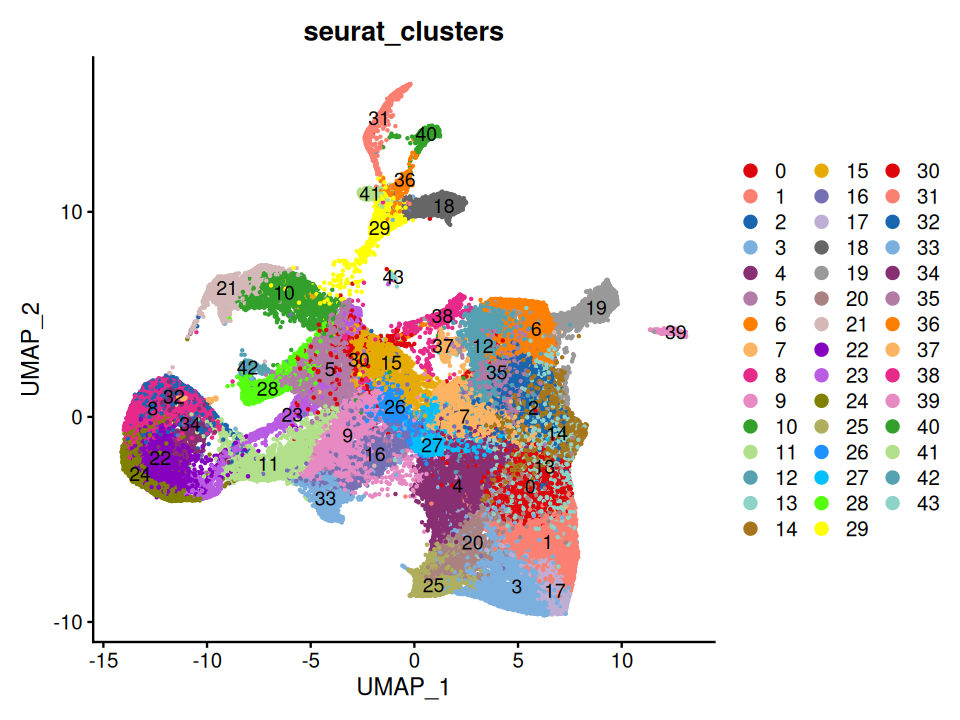

In [63]:
options(repr.plot.width =8, repr.plot.height=6)

DimPlot(AllTissue_merge,reduction = "umap",group.by = c('seurat_clusters'),label = T,raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))


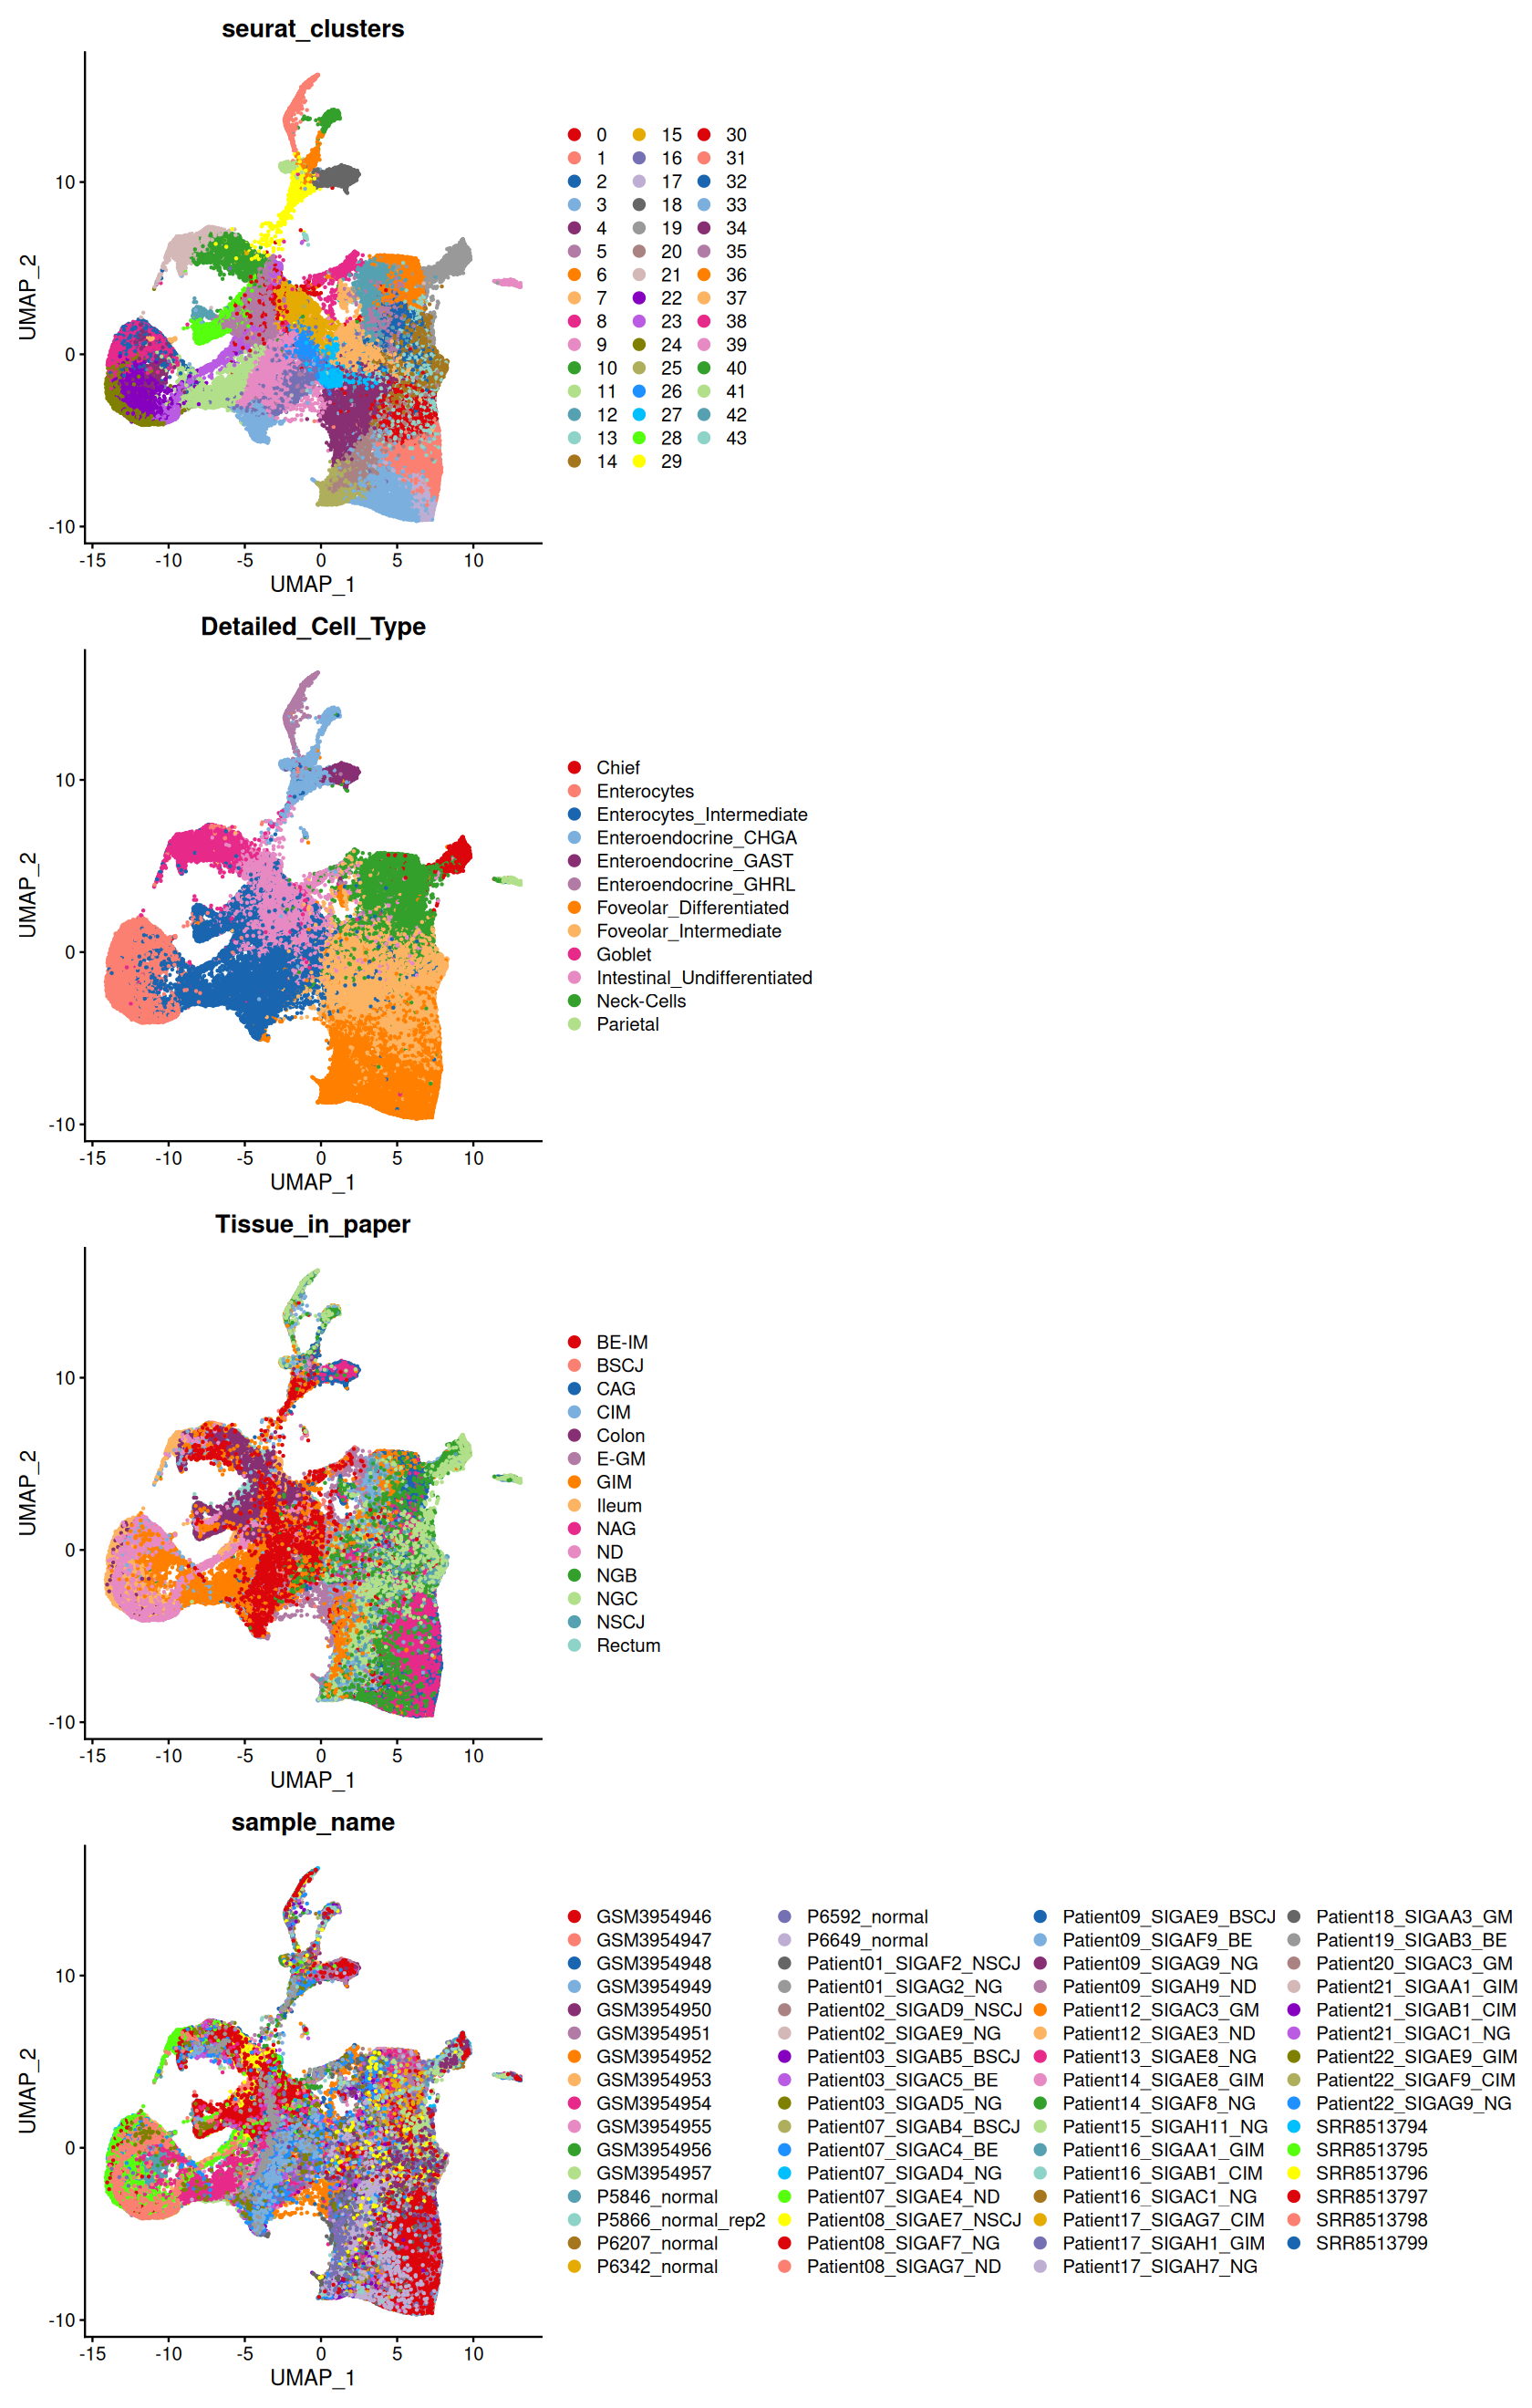

In [64]:
options(repr.plot.width =14, repr.plot.height=22)

DimPlot(AllTissue_merge,reduction = "umap",group.by = c("seurat_clusters","Detailed_Cell_Type","Tissue_in_paper",'sample_name'),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))



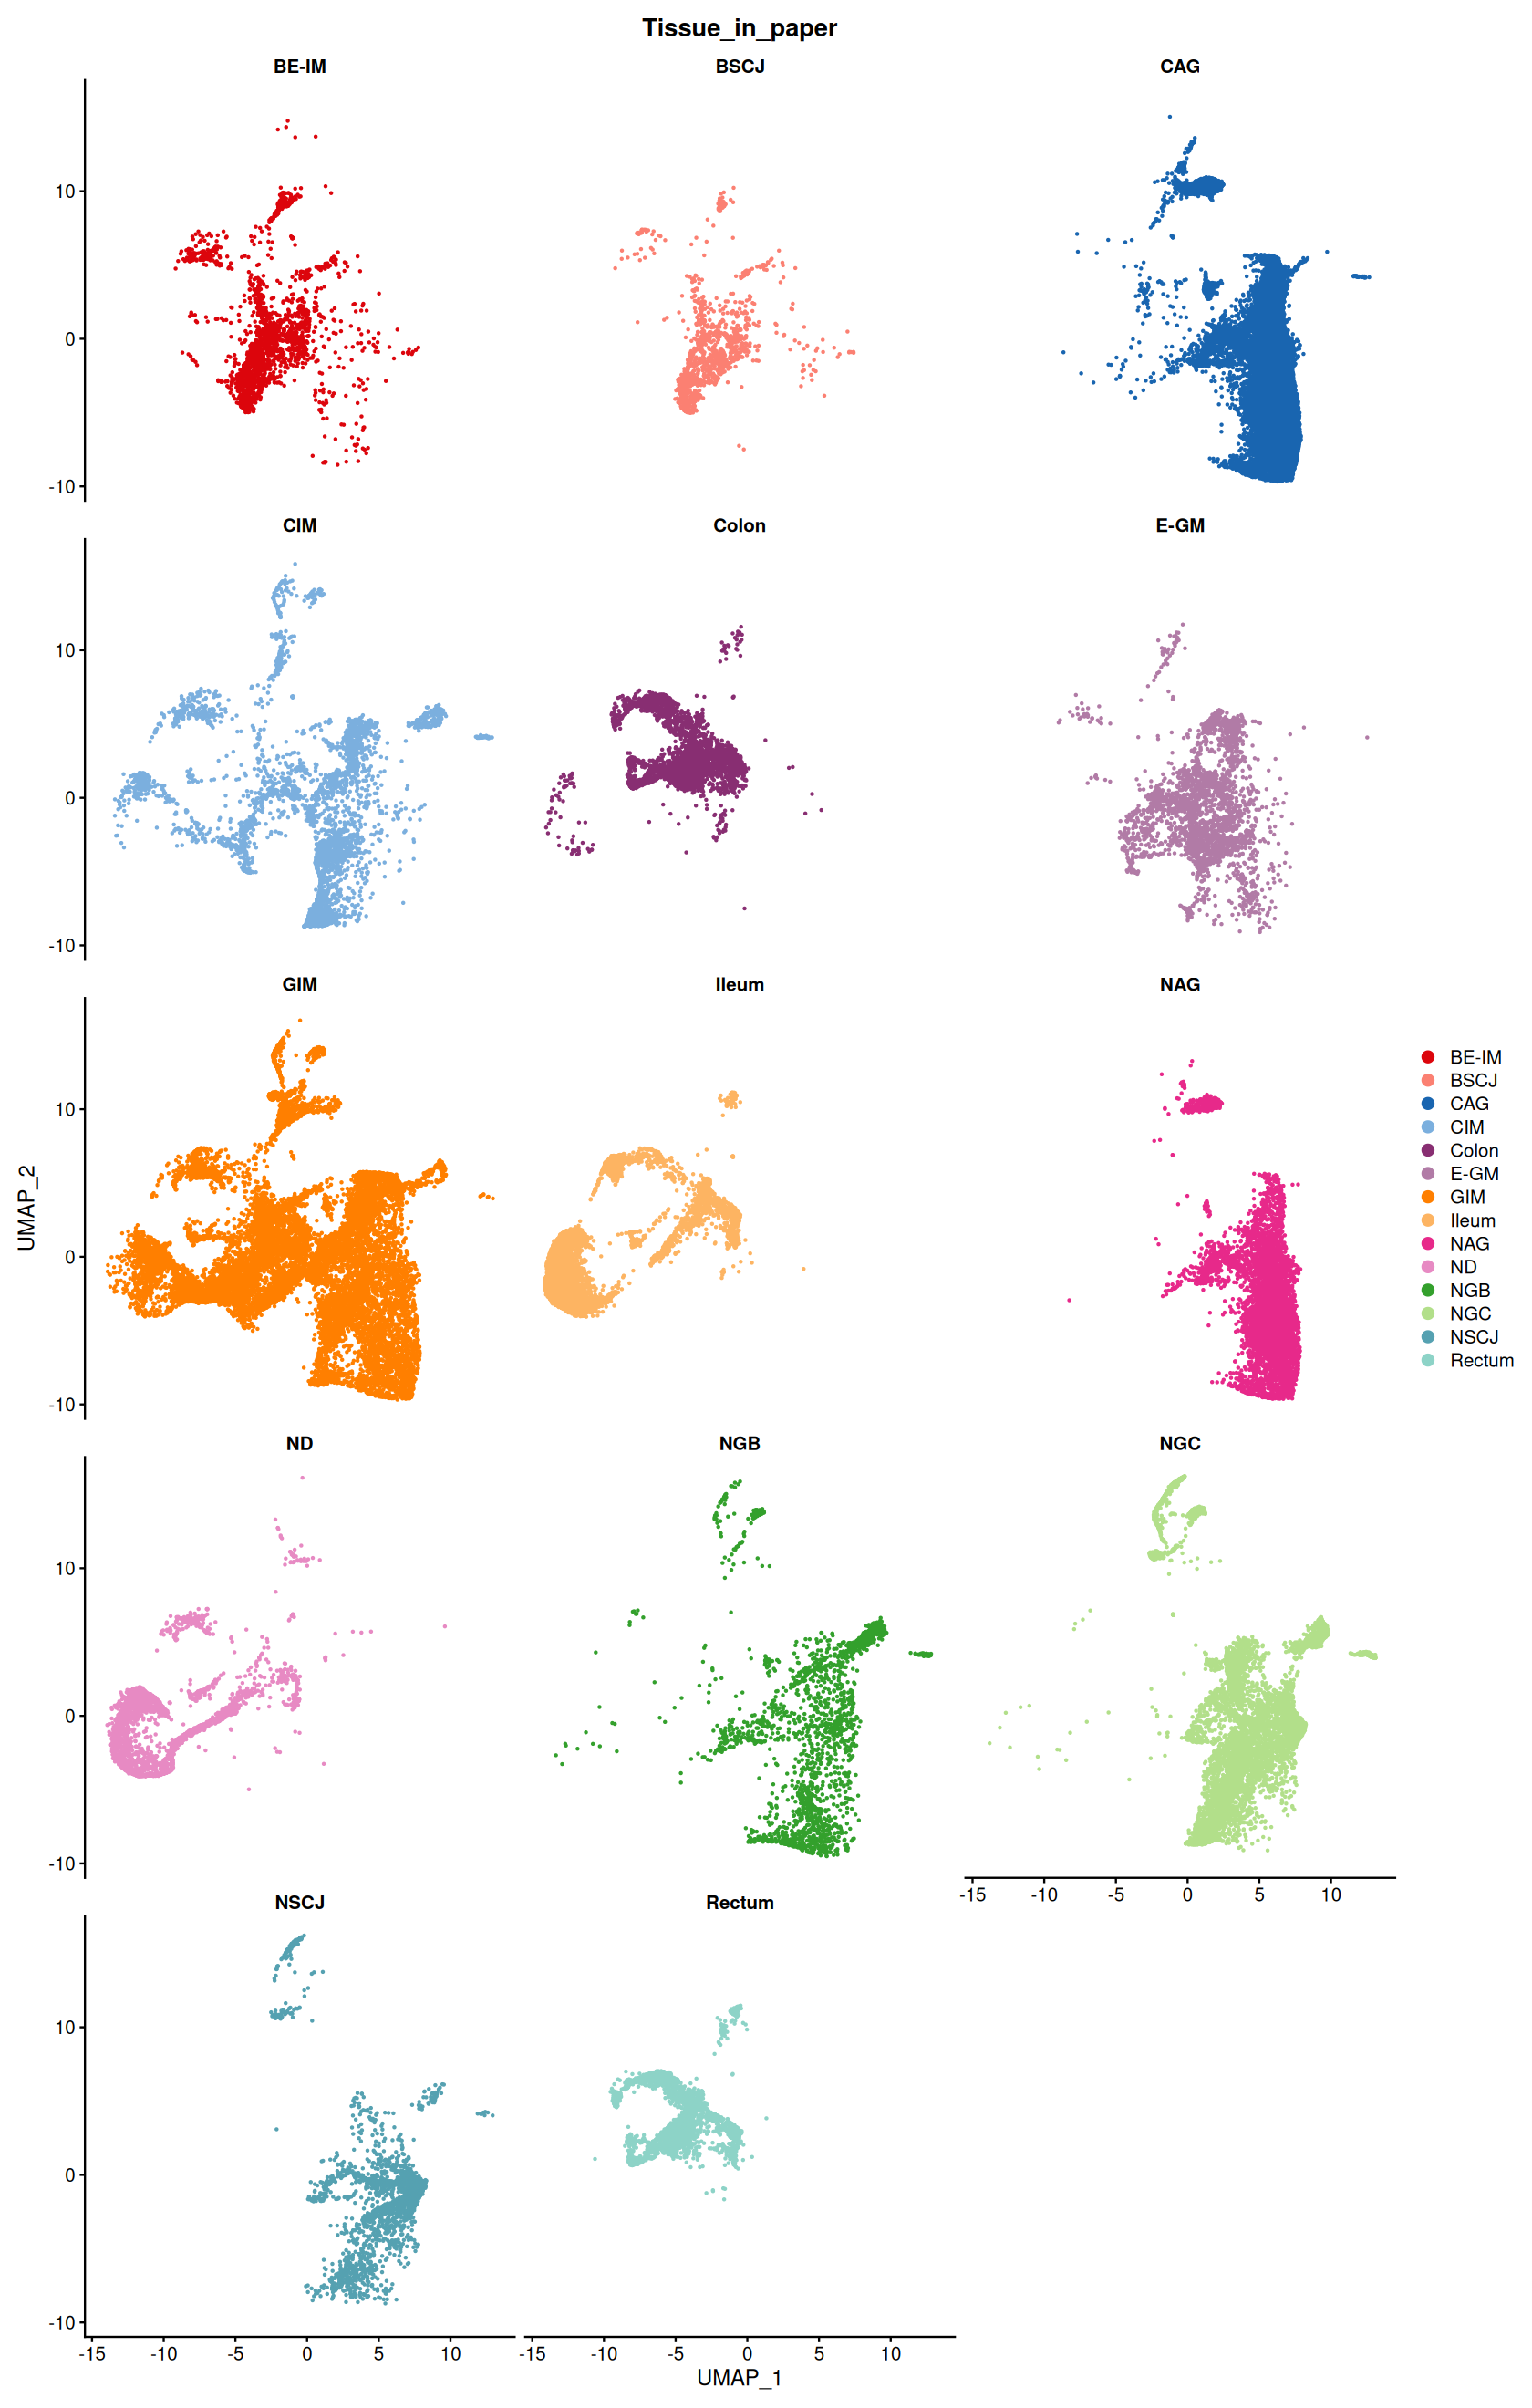

In [66]:
DimPlot(AllTissue_merge,reduction = "umap",
        group.by = c("Tissue_in_paper"),split.by ='Tissue_in_paper', raster=FALSE,pt.size = 0.2,ncol = 3,cols =  rep(cluster_cols,3))

Computing nearest neighbor graph

Computing SNN

12:31:44 UMAP embedding parameters a = 0.9922 b = 1.112

12:31:44 Read 78502 rows and found 25 numeric columns

12:31:44 Using Annoy for neighbor search, n_neighbors = 30

12:31:44 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:31:52 Writing NN index file to temp file /tmp/RtmpemimyY/file1b86ef317f3493

12:31:52 Searching Annoy index using 1 thread, search_k = 3000

12:32:15 Annoy recall = 99.88%

12:32:16 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

12:32:17 160 smooth knn distance failures

12:32:19 Initializing from normalized Laplacian + noise (using irlba)

12:32:22 Commencing optimization for 200 epochs, with 3367706 positive edges

12:32:22 Using rng type: pcg

12:32

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 78502
Number of edges: 2545814

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8991
Number of communities: 35
Elapsed time: 12 seconds


Computing nearest neighbor graph

Computing SNN

12:33:10 UMAP embedding parameters a = 0.9922 b = 1.112

12:33:10 Read 78502 rows and found 30 numeric columns

12:33:10 Using Annoy for neighbor search, n_neighbors = 30

12:33:10 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:33:17 Writing NN index file to temp file /tmp/RtmpemimyY/file1b86ef7d31f58b

12:33:17 Searching Annoy index using 1 thread, search_k = 3000

12:33:41 Annoy recall = 100%

12:33:42 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

12:33:42 35 smooth knn distance failures

12:33:45 Initializing from normalized Laplacian + noise (using irlba)

12:33:47 Commencing optimization for 200 epochs, with 3370882 positive edges

12:33:47 Using rng type: pcg

12:34:09

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 78502
Number of edges: 2589991

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9009
Number of communities: 36
Elapsed time: 13 seconds


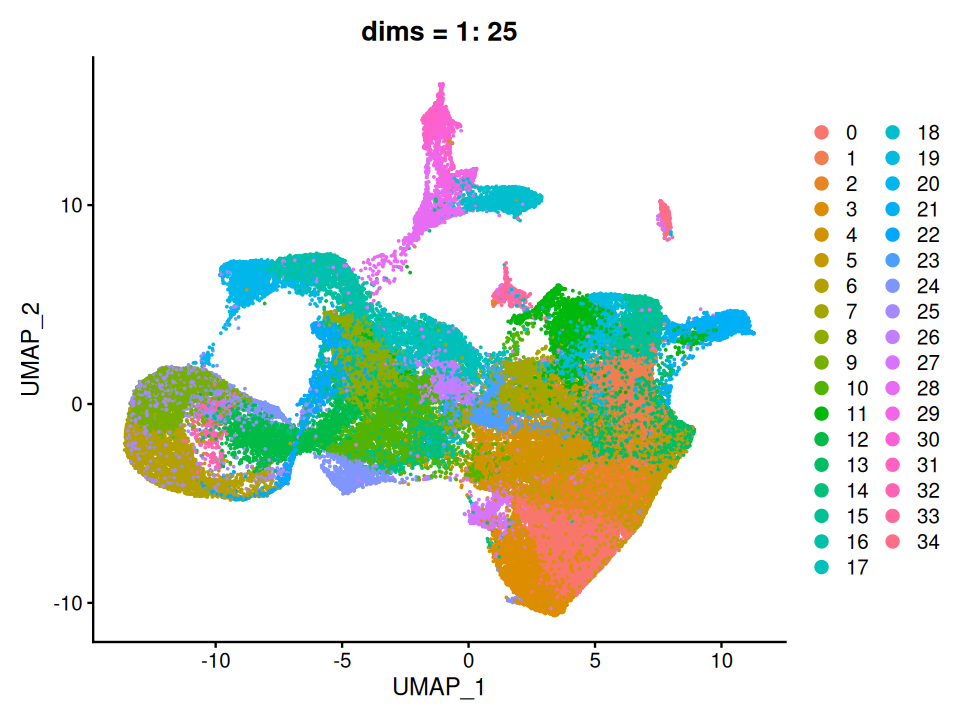

ERROR: Error in FindNeighbors.Seurat(AllTissue_merge, dims = 1:k, reduction = "Consensus"): More dimensions specified in dims than have been computed


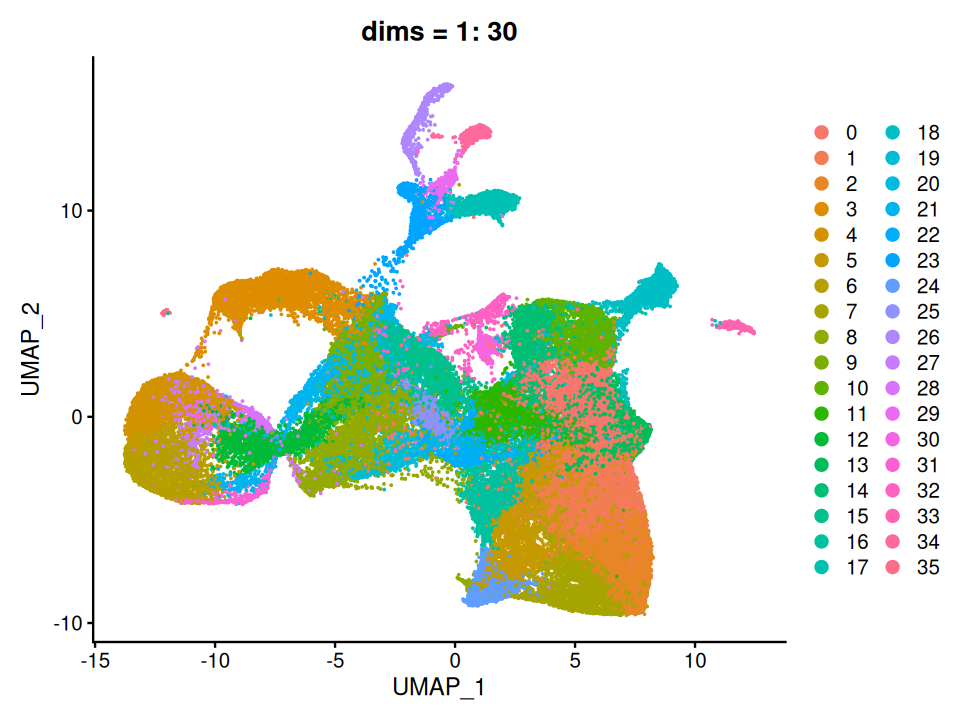

In [67]:
options(repr.plot.width =8, repr.plot.height=6)

for (k in c(25,30,35)) {
  AllTissue_merge <- FindNeighbors(AllTissue_merge, dims = 1:k, reduction = 'Consensus')
  AllTissue_merge <- RunUMAP(AllTissue_merge, dims = 1:k, reduction = 'Consensus')
  AllTissue_merge <- FindClusters(AllTissue_merge, resolution = 1)
  
  p <- DimPlot(AllTissue_merge, group.by = 'seurat_clusters') + ggtitle(paste("dims = 1:", k))
  print(p)
}


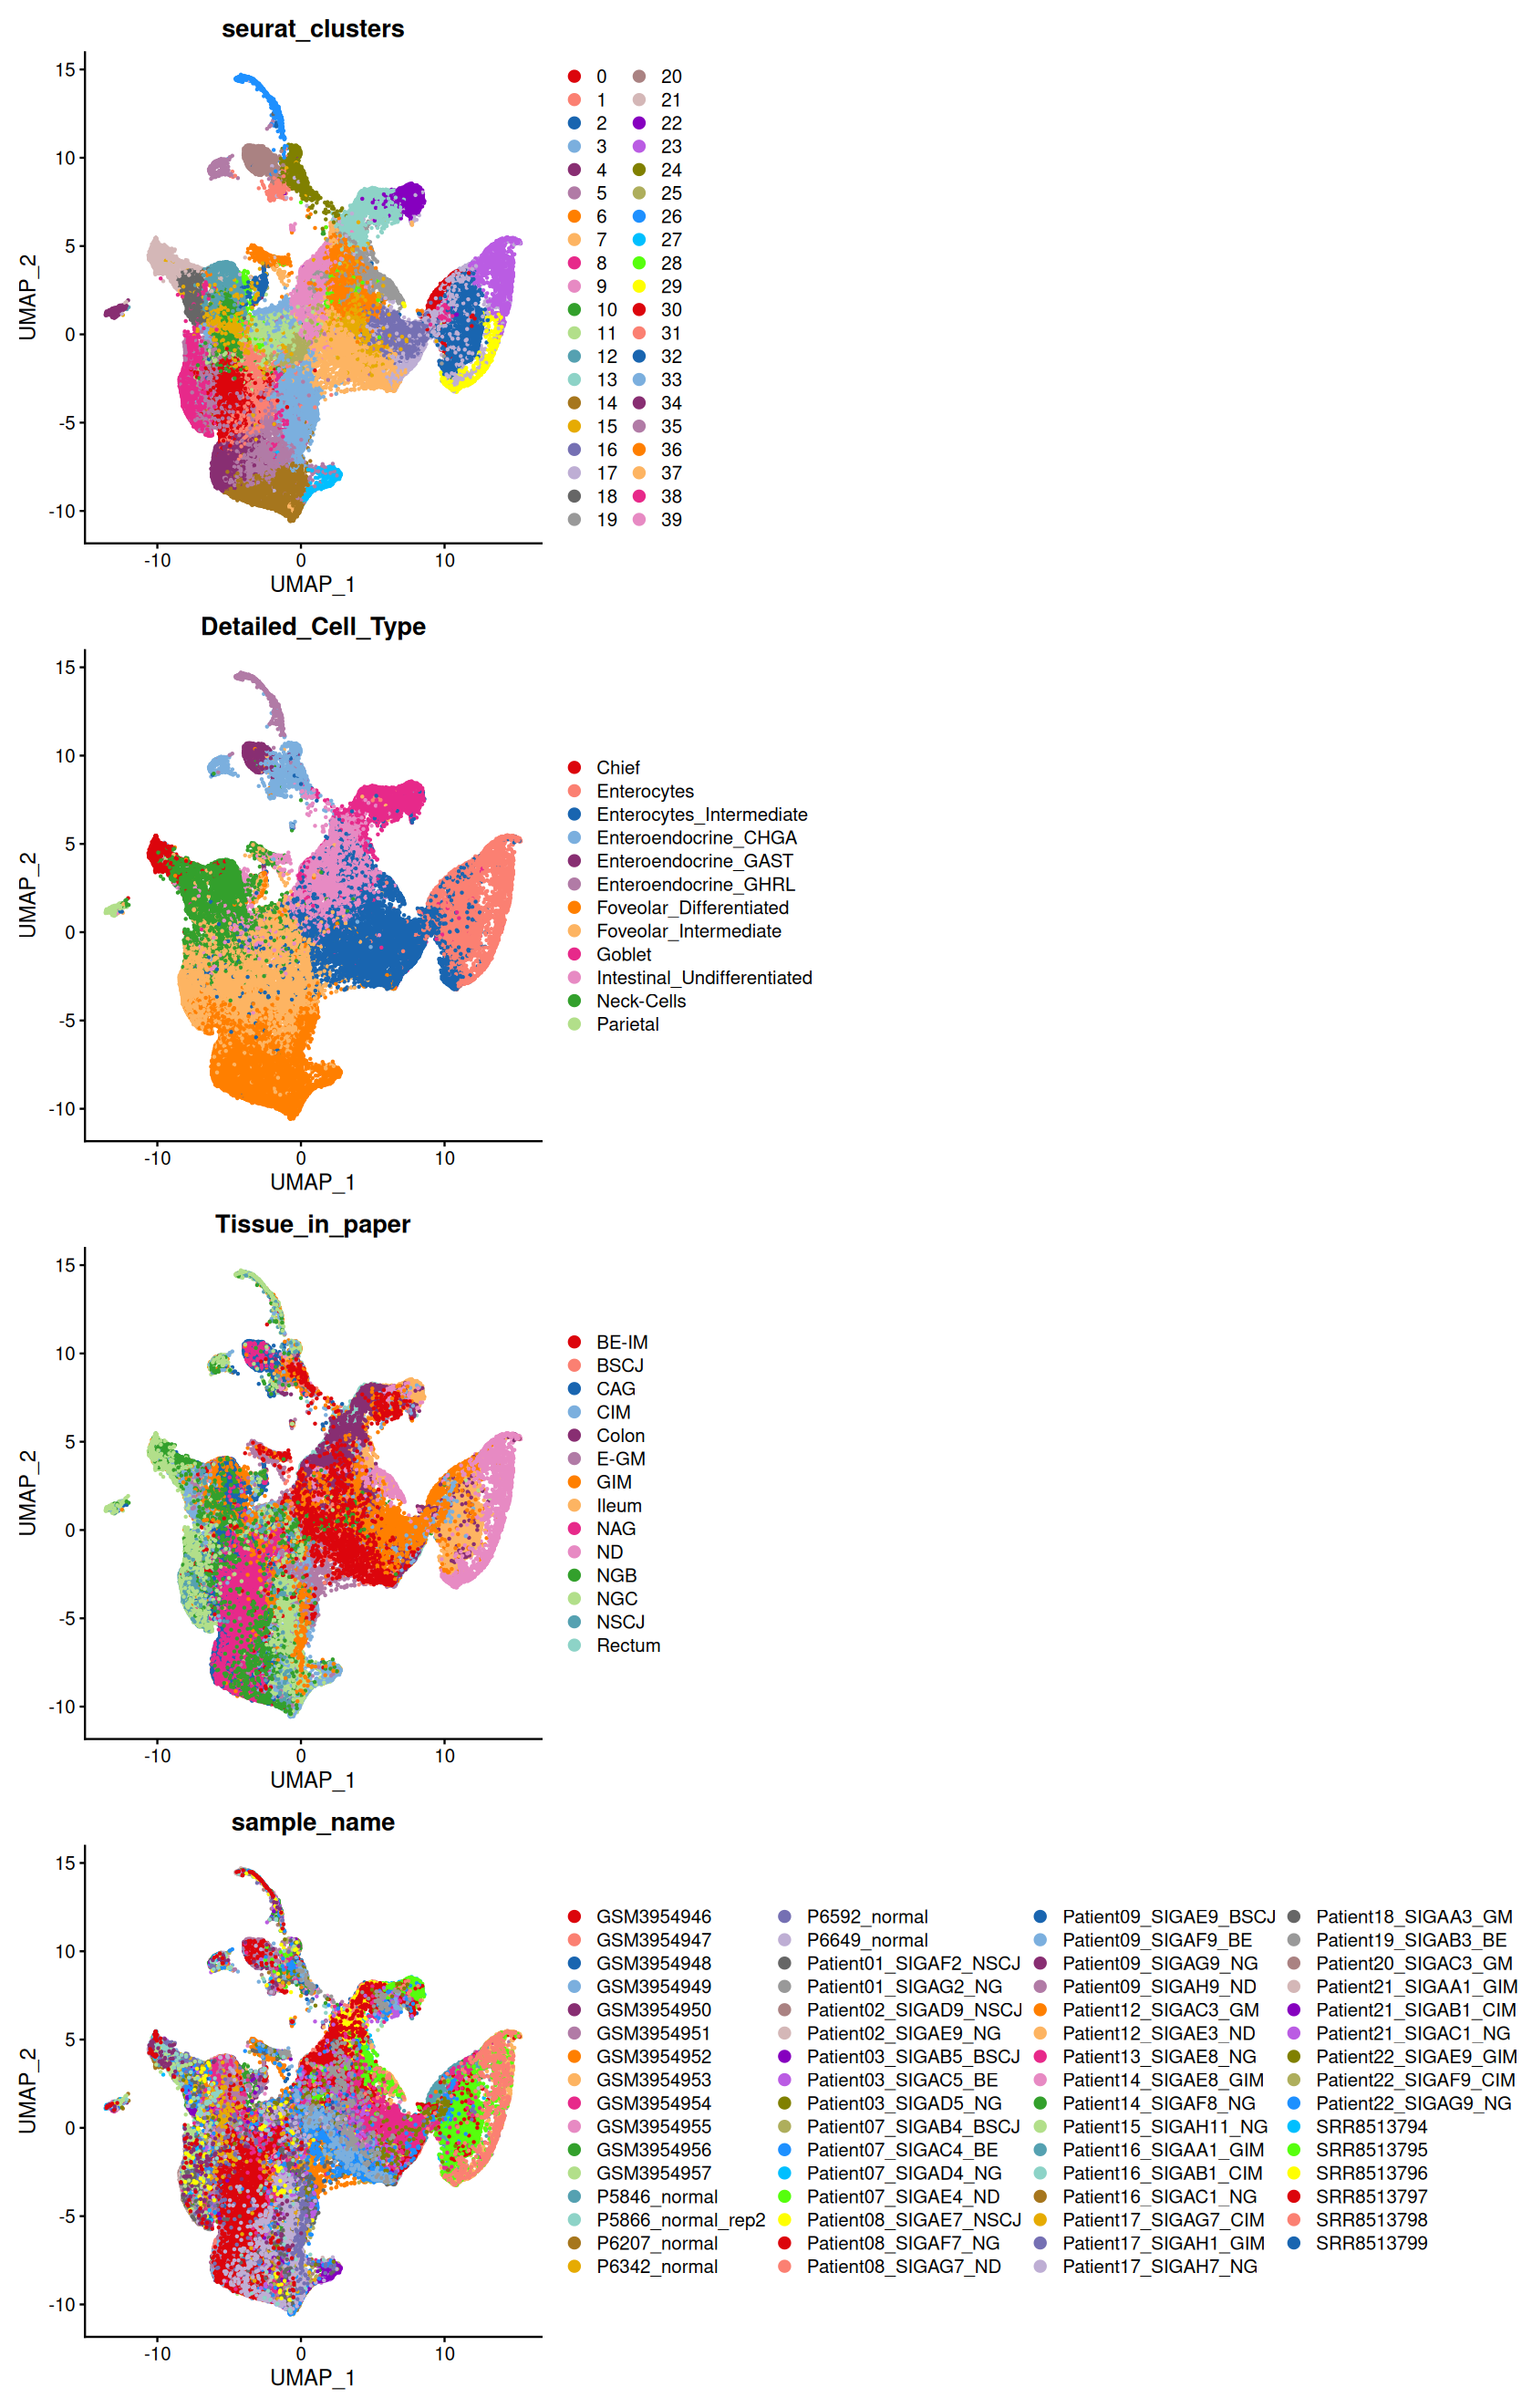

In [314]:
options(repr.plot.width =14, repr.plot.height=22)

DimPlot(AllTissue_merge,reduction = "umap",group.by = c("seurat_clusters","Detailed_Cell_Type","Tissue_in_paper",'sample_name'),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))



In [70]:
?setParams

In [ ]:
hvg_freq_df <- readRDS('./')